# Notebook 04: Model 2 — Anomaly Detection and Diagnosis

**Project:** MAP Dryer AI  
**Purpose:** detect unusual multivariate dryer states and convert persistent alerts into cautious, evidence-based diagnostic events.

The notebook develops and compares unsupervised detectors, applies a two-of-three persistence rule and PCS7-style prototype limit checks, and evaluates transparent D01–D08 diagnostic rules.

## Inputs and outputs

- **Input:** `data/processed/dryerMAP_prototype_processed_2.csv`
- **Figure outputs:** `figures/04_Model2_Anomaly_and_Diagnosis/`
- **Diagnostic metadata:** `models/diagnosis/`
- **Prototype feature dictionary:** `config/data_dictionary.yaml`


## 1. Define the anomaly-detection objective

The objective is to identify **multivariate dryer states that differ materially from the prototype's normal reference pattern**. Each timestamped row is one observation. A detector learns from the chronological reference period, assigns a continuous anomaly score to each row, and marks rows whose score crosses its threshold as raw anomaly candidates.

A raw candidate only means that the combination of measurements is unusual. Persistence decides whether the unusual state lasts long enough to become an alarm, and the diagnostic layer then ranks the features, subsystems, and D01–D08 rules that best explain the episode.

### Prototype success criteria

- Produce one reproducible anomaly score and threshold decision per timestamp.
- Keep raw candidates separate from persistent alarms.
- Compare detectors using the same chronological splits and scenario suite.
- Explain persistent episodes with traceable feature evidence and diagnostic rules.


## Setup: import libraries and locate the project root

Load the libraries needed for data handling and later anomaly modelling. The project-root pattern is the same as in the preceding notebooks, so the notebook runs from either the repository root or the `notebooks/` directory.


In [1]:
from itertools import product
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from anomaly.scoring import canonical_anomaly_score
from anomaly.thresholds import calibrate_conformal_threshold, candidate_rate
from anomaly.scoring import build_anomaly_score_table
from anomaly.scenarios import build_synthetic_validation_scenario
from anomaly.preprocessing import build_scaled_feature_table
from anomaly.persistence import apply_persistence_logic
from anomaly.evaluation import detector_comparison_row
from anomaly.alarms import LIMIT_ORDER, attach_pcs7_hybrid_alarm_state, evaluate_pcs7_limits
from data.feature_catalog import (
    load_feature_catalog,
    select_feature_catalog,
)
from data.project_paths import find_project_root
from diagnosis.bundle import save_diagnostic_bundle_metadata
from diagnosis.config import load_diagnostic_configuration, validate_model_features
from diagnosis.engine import diagnose_anomaly, format_operator_report
from diagnosis.reference_profile import build_reference_profile
from diagnosis.scenarios import build_physical_scenarios
from features.engineering import ENGINEERED_FEATURES, RAW_PROCESS_FEATURES

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "04_Model2_Anomaly_and_Diagnosis"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DICTIONARY_PATH = PROJECT_ROOT / "config" / "data_dictionary.yaml"
feature_catalog = load_feature_catalog(DATA_DICTIONARY_PATH)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Prototype feature dictionary


In [2]:
ANOMALY_NOTEBOOK_FIELDS = [
    "timestamp", "dryer_air_temperature", "cooler_air_temperature",
    "air_flow_rate", "wet_product_feed_rate", "product_inlet_temperature",
    "residence_time", "vacuum", "steam_pressure", "fan_speed",
    "product_density", "final_product_temp", "temperature_drop",
    "air_product_delta", "air_per_feed", "steam_temp_interaction",
    "heating_index", "final_moisture_h₂o",
]
display(select_feature_catalog(feature_catalog, ANOMALY_NOTEBOOK_FIELDS))
print("Data dictionary version:", feature_catalog.attrs["version"])


,display_name,unit,unit_status,role,interpretation
feature,,,,,
timestamp,Timestamp,datetime,defined,identifier,Date and time combined for chronological order...
dryer_air_temperature,Dryer air temperature,°C,prototype_unit,process_input,Dryer inlet-air temperature.
cooler_air_temperature,Cooler air temperature,°C,prototype_unit,process_input,Cooling-air temperature.
air_flow_rate,Air flow rate,m³/h,defined,process_input,Volumetric airflow rate in cubic metres per hour.
wet_product_feed_rate,Wet product feed rate,m³/h,defined,process_input,Volumetric wet-product feed rate in cubic metr...
product_inlet_temperature,Product inlet temperature,°C,prototype_unit,process_input,Product temperature at dryer entry.
residence_time,Residence time,min,prototype_unit,process_input,Time spent in the drying process.
vacuum,Vacuum,mmH2O,defined,process_input,Vacuum in millimetres of water column; more-ne...
steam_pressure,Steam pressure,bar,defined,process_input,Steam pressure in bar.


Data dictionary version: map_dryer_data_dictionary_v1.2


### Interpretation guardrails

- A raw anomaly candidate is one above-threshold row; it is not yet a persistent alarm.
- A persistent alarm requires at least two candidates within the current three-observation window. One isolated candidate between two normal observations does not pass this gate.
- Isolation Forest and OCSVM each keep their own score scale and threshold, even though both are oriented so higher means more abnormal.
- Diagnostic confidence measures rule-evidence agreement; severity is a separate relative-priority score.
- Scenario `PASS` checks detector/rule logic and explicitly bypasses the persistence gate.


## 2. Load the processed dryer dataset

Read the processed feature table created in Notebook 02 and parse its temporal columns. This uses the same data path and loading code as Notebook 03.


In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed_2.csv"

dryerMAP_model = pd.read_csv(
    DATA_PATH,
    parse_dates=["date", "timestamp"]
)

dryerMAP_model["time"] = dryerMAP_model["time"].astype(str)

display(dryerMAP_model.head())
dryerMAP_model.info()


,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.00,47.7,20.96,-1.18,4.69,1270.0,1.023,41.0,0.075,2026-04-23 01:00:00,98.0,91.3,2.362000,651.910,2913.440
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.20,46.6,20.29,-0.63,4.78,1236.0,1.028,43.7,0.087,2026-04-23 03:00:00,96.0,93.1,2.384314,667.766,2834.513
2,2026-04-23,05:00:00,140.1,18.9,23.80,10.25,47.3,20.36,-1.08,4.81,1272.0,1.034,45.7,0.072,2026-04-23 05:00:00,94.4,92.8,2.321951,673.881,2852.436
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238.0,1.033,45.2,0.094,2026-04-23 07:00:00,94.5,91.6,2.273612,666.369,2828.925
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.10,4.84,1267.0,1.025,42.9,0.084,2026-04-23 09:00:00,96.9,93.3,2.264734,676.632,2934.402


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   str           
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   float64       
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 3. Select detector input features

Select direct process measurements and the engineered indicators created in Notebook 02. The explicit list defines the detector input order and avoids confusing **input features** with **raw anomaly candidates**, which are scored observations produced later.


In [4]:
DIRECT_PROCESS_FEATURES = list(RAW_PROCESS_FEATURES)
ENGINEERED_PROCESS_FEATURES = list(ENGINEERED_FEATURES)

ANOMALY_FEATURES = DIRECT_PROCESS_FEATURES + ENGINEERED_PROCESS_FEATURES

missing_features = [
    feature for feature in ANOMALY_FEATURES if feature not in dryerMAP_model.columns
]
if missing_features:
    raise KeyError(f"Selected anomaly features are missing: {missing_features}")

anomaly_feature_catalog = pd.DataFrame(
    {
        "Feature": ANOMALY_FEATURES,
        "Feature group": (
            ["Direct process measurement"] * len(DIRECT_PROCESS_FEATURES)
            + ["Engineered process indicator"] * len(ENGINEERED_PROCESS_FEATURES)
        ),
    }
)

X_anomaly_candidates = dryerMAP_model[ANOMALY_FEATURES].copy()

display(anomaly_feature_catalog)
print(f"Selected detector input features: {len(ANOMALY_FEATURES)}")
print(f"Detector input matrix shape: {X_anomaly_candidates.shape}")


,Feature,Feature group
0,dryer_air_temperature,Direct process measurement
1,cooler_air_temperature,Direct process measurement
2,air_flow_rate,Direct process measurement
3,wet_product_feed_rate,Direct process measurement
4,product_inlet_temperature,Direct process measurement
5,residence_time,Direct process measurement
6,vacuum,Direct process measurement
7,steam_pressure,Direct process measurement
8,fan_speed,Direct process measurement
9,product_density,Direct process measurement


Selected detector input features: 16
Detector input matrix shape: (1080, 16)


## 4. Exclude identifiers and the prediction target

Keep `timestamp` only for chronological ordering and reporting. Exclude `date`, `time`, and `final_moisture_h₂o` from anomaly detection so the unsupervised detector uses only the numerical process-state features listed above.


In [5]:
EXCLUDED_COLUMNS = {
    "date": "Administrative calendar field; not a process-state measurement.",
    "time": "Administrative clock field; not a process-state measurement.",
    "timestamp": "Retained separately for ordering and reporting only.",
    "final_moisture_h₂o": (
        "Prediction target; excluded from unsupervised detector inputs."
    ),
}

missing_excluded_columns = [
    column for column in EXCLUDED_COLUMNS if column not in dryerMAP_model.columns
]
if missing_excluded_columns:
    raise KeyError(f"Expected excluded columns are missing: {missing_excluded_columns}")

unreviewed_columns = sorted(
    set(dryerMAP_model.columns)
    - set(ANOMALY_FEATURES)
    - set(EXCLUDED_COLUMNS)
)
if unreviewed_columns:
    raise ValueError(f"Columns are not assigned to detector inputs or exclusions: {unreviewed_columns}")

MODEL_FEATURES = [
    feature for feature in ANOMALY_FEATURES if feature not in EXCLUDED_COLUMNS
]
X_anomaly = dryerMAP_model[MODEL_FEATURES].copy()

if not X_anomaly.select_dtypes(exclude="number").empty:
    raise TypeError("All anomaly-model inputs must be numeric.")

detector_input_audit = pd.DataFrame(
    [
        {
            "Column": column,
            "Detector input": "No" if column in EXCLUDED_COLUMNS else "Yes",
            "Decision": (
                EXCLUDED_COLUMNS[column]
                if column in EXCLUDED_COLUMNS
                else "Retained numerical process measurement or derived feature."
            ),
        }
        for column in dryerMAP_model.columns
    ]
)

display(detector_input_audit)
print(f"Final detector inputs: {len(MODEL_FEATURES)}")
print("Excluded columns:", list(EXCLUDED_COLUMNS))


,Column,Detector input,Decision
0,date,No,Administrative calendar field; not a process-s...
1,time,No,Administrative clock field; not a process-stat...
2,dryer_air_temperature,Yes,Retained numerical process measurement or deri...
3,cooler_air_temperature,Yes,Retained numerical process measurement or deri...
4,air_flow_rate,Yes,Retained numerical process measurement or deri...
5,wet_product_feed_rate,Yes,Retained numerical process measurement or deri...
6,product_inlet_temperature,Yes,Retained numerical process measurement or deri...
7,residence_time,Yes,Retained numerical process measurement or deri...
8,vacuum,Yes,Retained numerical process measurement or deri...
9,steam_pressure,Yes,Retained numerical process measurement or deri...


Final detector inputs: 16
Excluded columns: ['date', 'time', 'timestamp', 'final_moisture_h₂o']


### PCS7-style prototype limit checks

The values below demonstrate LL/L/H/HH rule logic alongside the machine-learning detector. `L` and `H` are warning boundaries; `LL` and `HH` are critical boundaries. Checks use the original prototype units before scaling. The Boolean configuration remains `False`, so these rule results are displayed in the hybrid timeline but do not remove rows from the model's normal reference.


In [6]:
# PCS7-style prototype limits used by the hybrid rule demonstration.
PCS7_LIMIT_CONFIGURATION_MODE = (
    "PROTOTYPE: LL/L/H/HH rule demonstration"
)
USE_PCS7_LIMITS_FOR_REFERENCE_FILTER = False
PCS7_FEATURE_LIMITS = {
    "dryer_air_temperature": {"LL": 136.5, "L": 137.1, "H": 141.6, "HH": 142.5, "unit": feature_catalog.loc["dryer_air_temperature", "unit"]},
    "cooler_air_temperature": {"LL": 18.0, "L": 18.5, "H": 31.9, "HH": 33.0, "unit": feature_catalog.loc["cooler_air_temperature", "unit"]},
    "air_flow_rate": {"LL": 21.2, "L": 22.0, "H": 25.8, "HH": 26.5, "unit": feature_catalog.loc["air_flow_rate", "unit"]},
    "wet_product_feed_rate": {"LL": 9.2, "L": 9.37, "H": 10.92, "HH": 11.1, "unit": feature_catalog.loc["wet_product_feed_rate", "unit"]},
    "product_inlet_temperature": {"LL": 43.5, "L": 44.4, "H": 51.2, "HH": 51.7, "unit": feature_catalog.loc["product_inlet_temperature", "unit"]},
    "residence_time": {"LL": 18.6, "L": 19.0, "H": 21.94, "HH": 22.5, "unit": feature_catalog.loc["residence_time", "unit"]},
    "vacuum": {"LL": -2.2, "L": -1.87, "H": -0.45, "HH": -0.4, "unit": feature_catalog.loc["vacuum", "unit"]},
    "steam_pressure": {"LL": 4.3, "L": 4.43, "H": 5.16, "HH": 5.25, "unit": feature_catalog.loc["steam_pressure", "unit"]},
    "fan_speed": {"LL": 1160.0, "L": 1193.0, "H": 1344.0, "HH": 1380.0, "unit": feature_catalog.loc["fan_speed", "unit"]},
    "product_density": {"LL": 1.008, "L": 1.014, "H": 1.039, "HH": 1.042, "unit": feature_catalog.loc["product_density", "unit"]},
    "final_product_temp": {"LL": 36.0, "L": 37.7, "H": 48.1, "HH": 49.0, "unit": feature_catalog.loc["final_product_temp", "unit"]},
}

unexpected_limit_features = sorted(
    set(PCS7_FEATURE_LIMITS) - set(DIRECT_PROCESS_FEATURES)
)
if unexpected_limit_features:
    raise KeyError(
        f"PCS7 limits contain unrecognized features: {unexpected_limit_features}"
    )

limit_configuration_rows = []
for feature in DIRECT_PROCESS_FEATURES:
    feature_limits = PCS7_FEATURE_LIMITS[feature]
    configured_pairs = [
        (limit_name, feature_limits[limit_name])
        for limit_name in LIMIT_ORDER
        if feature_limits[limit_name] is not None
    ]
    configured_values = [value for _, value in configured_pairs]
    if configured_values != sorted(configured_values):
        raise ValueError(
            f"PCS7 limits for {feature} must satisfy LL <= L <= H <= HH."
        )
    limit_configuration_rows.append(
        {
            "Feature": feature,
            "LL": feature_limits["LL"],
            "L": feature_limits["L"],
            "H": feature_limits["H"],
            "HH": feature_limits["HH"],
            "Unit": feature_limits["unit"],
            "Configured limits": len(configured_pairs),
        }
    )

pcs7_limit_configuration = pd.DataFrame(limit_configuration_rows).set_index("Feature")
CONFIGURED_PCS7_LIMIT_COUNT = int(
    pcs7_limit_configuration["Configured limits"].sum()
)
CONFIGURED_PCS7_FEATURE_COUNT = int(
    (pcs7_limit_configuration["Configured limits"] > 0).sum()
)

pcs7_limit_results = evaluate_pcs7_limits(
    dryerMAP_model, PCS7_FEATURE_LIMITS, DIRECT_PROCESS_FEATURES
)
display(pcs7_limit_configuration)
print("PCS7 limit mode:", PCS7_LIMIT_CONFIGURATION_MODE)
print("Used for reference-data filtering:", USE_PCS7_LIMITS_FOR_REFERENCE_FILTER)
print(
    f"PCS7 configuration coverage: {CONFIGURED_PCS7_FEATURE_COUNT}/"
    f"{len(DIRECT_PROCESS_FEATURES)} features, "
    f"{CONFIGURED_PCS7_LIMIT_COUNT} individual limits."
)
if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "PCS7-style rule alarms are inactive because no limits are configured."
    )


,LL,L,H,HH,Unit,Configured limits
Feature,,,,,,
dryer_air_temperature,136.500,137.100,141.600,142.500,°C,4
cooler_air_temperature,18.000,18.500,31.900,33.000,°C,4
air_flow_rate,21.200,22.000,25.800,26.500,m³/h,4
wet_product_feed_rate,9.200,9.370,10.920,11.100,m³/h,4
product_inlet_temperature,43.500,44.400,51.200,51.700,°C,4
residence_time,18.600,19.000,21.940,22.500,min,4
vacuum,-2.200,-1.870,-0.450,-0.400,mmH2O,4
steam_pressure,4.300,4.430,5.160,5.250,bar,4
fan_speed,1160.000,1193.000,1344.000,1380.000,rpm,4


PCS7 limit mode: PROTOTYPE: LL/L/H/HH rule demonstration
Used for reference-data filtering: False
PCS7 configuration coverage: 11/11 features, 44 individual limits.


## 5. Inspect retained feature distributions

Review descriptive statistics and univariate distributions before defining the normal reference period. These plots reveal scale differences, skew, long tails, and possible data-quality issues; unusual tails are not automatically treated as anomalies at this stage because operating context still matters.


,Unit,Unit status,count,missing values,non-finite values,mean,std,min,25%,50%,75%,max,skewness
dryer_air_temperature,°C,prototype_unit,1080.0,0,0,139.3990,1.1026,136.3000,138.5000,139.4000,140.2000,142.8000,0.0088
cooler_air_temperature,°C,prototype_unit,1080.0,0,0,24.2626,3.4003,18.5000,21.5000,24.3000,26.7000,33.3000,0.1338
air_flow_rate,m³/h,defined,1080.0,0,0,23.8650,0.8460,21.0100,23.2500,23.8500,24.4325,27.0000,0.1207
wet_product_feed_rate,m³/h,defined,1080.0,0,0,10.1518,0.4017,9.1600,9.8200,10.1500,10.4700,11.1800,0.0151
product_inlet_temperature,°C,prototype_unit,1080.0,0,0,47.7766,1.5305,43.2000,46.7000,47.7000,48.8000,51.9000,0.0269
residence_time,min,prototype_unit,1080.0,0,0,20.5669,0.6563,18.4500,20.1100,20.5900,21.0025,22.6900,-0.1313
vacuum,mmH2O,defined,1080.0,0,0,-0.9975,0.3451,-2.3000,-1.2300,-0.9800,-0.7200,-0.4500,-0.3685
steam_pressure,bar,defined,1080.0,0,0,4.7890,0.1630,4.2700,4.6800,4.7900,4.9000,5.3000,0.0005
fan_speed,rpm,defined,1080.0,0,0,1264.7259,32.4984,1148.0000,1241.0000,1263.5000,1288.0000,1392.0000,0.1195
product_density,kg/L,prototype_unit,1080.0,0,0,1.0265,0.0052,1.0070,1.0230,1.0260,1.0300,1.0410,-0.0465


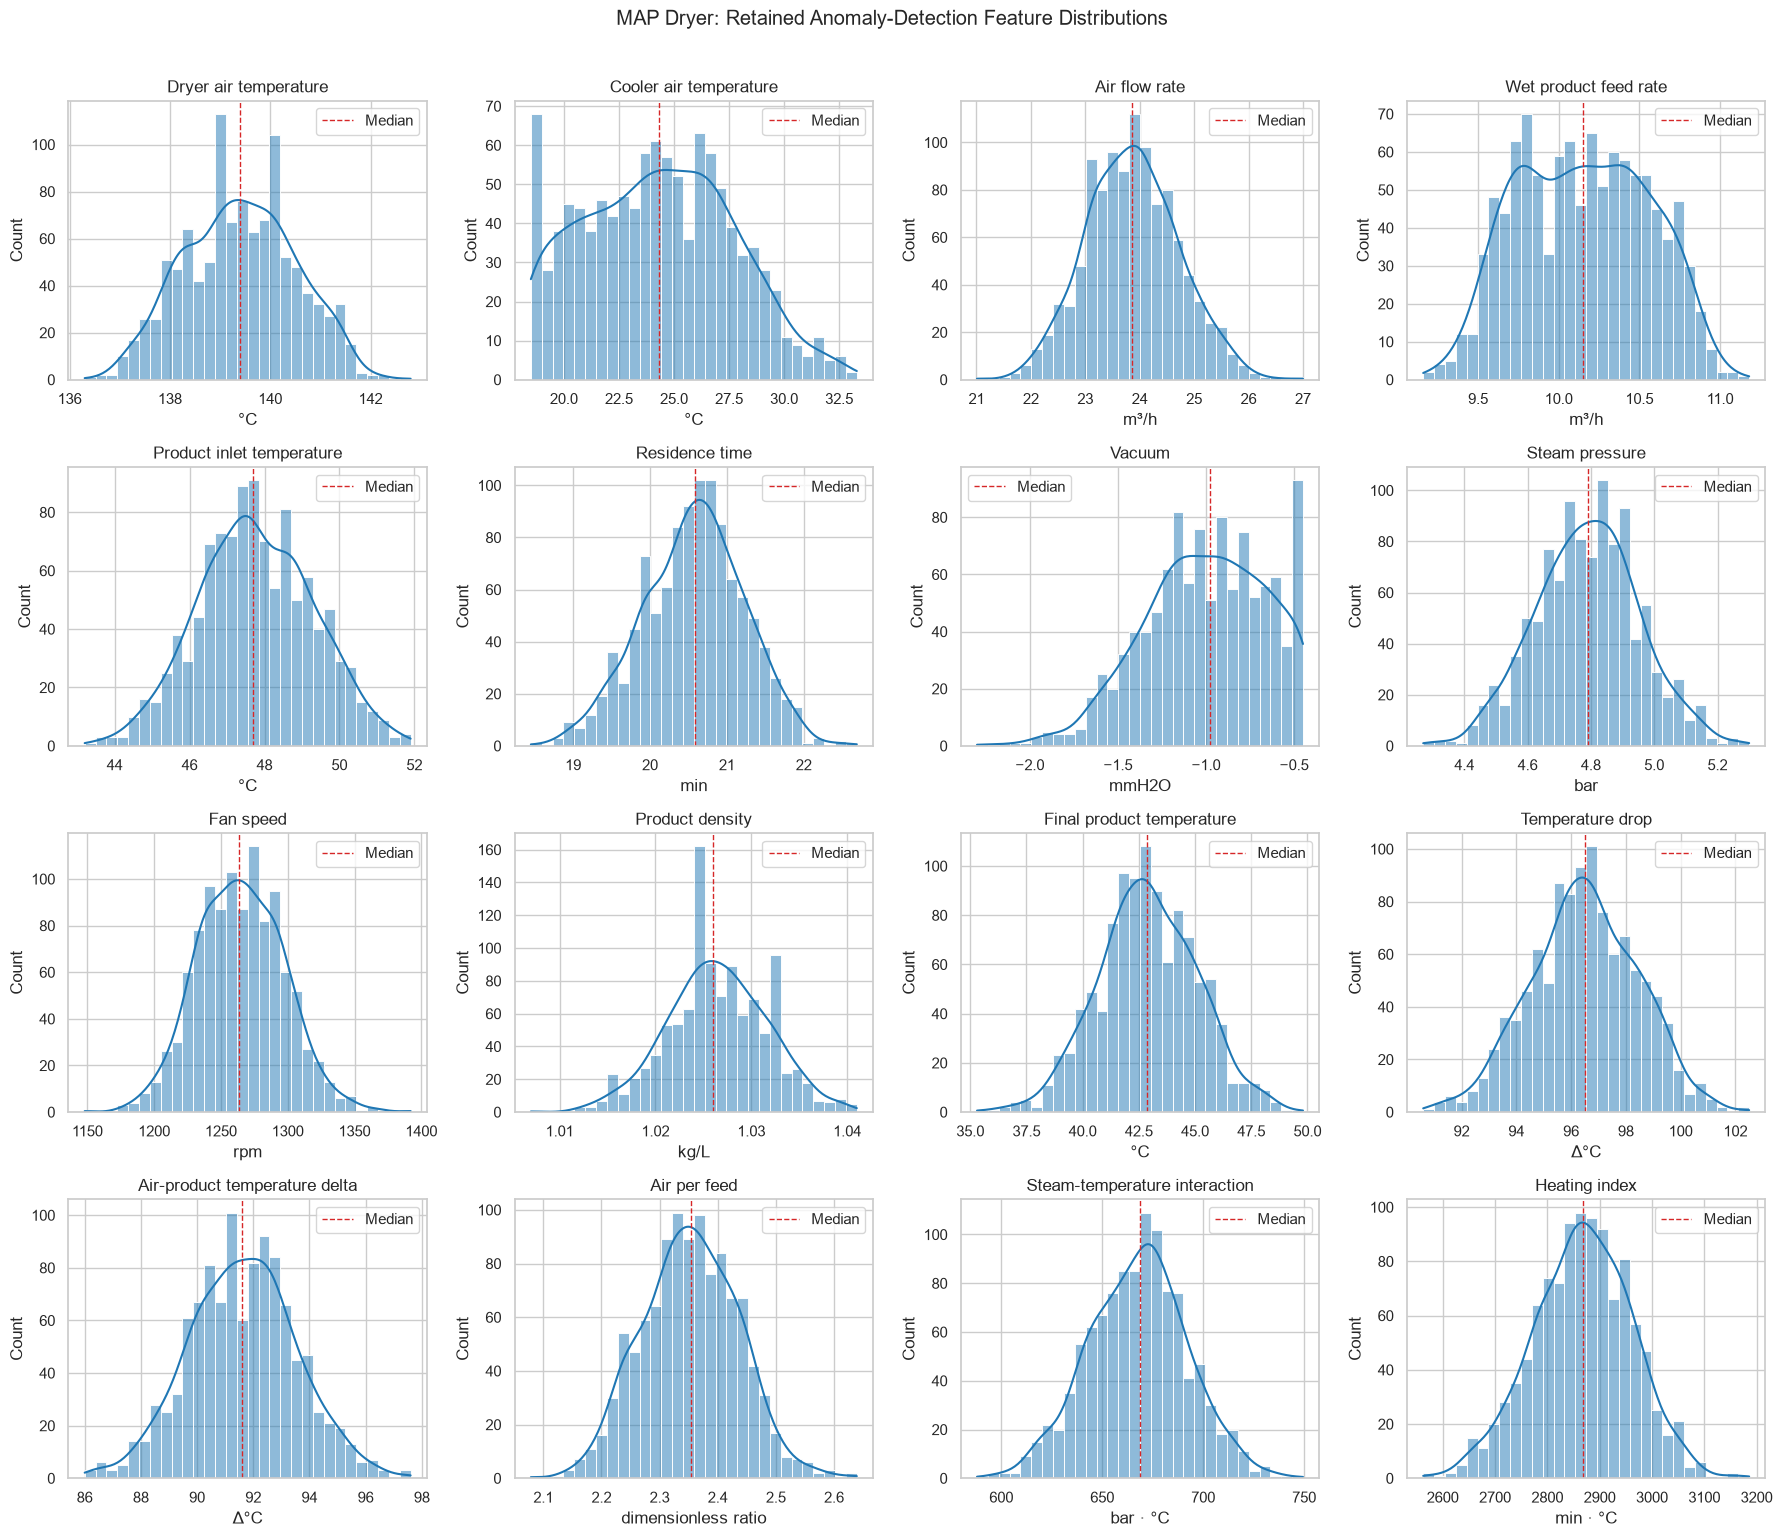

In [7]:
distribution_summary = X_anomaly.describe().T
distribution_summary["missing values"] = X_anomaly.isna().sum()
distribution_summary["non-finite values"] = (
    ~np.isfinite(X_anomaly)
).sum()
distribution_summary["skewness"] = X_anomaly.skew()
distribution_summary = distribution_summary[
    [
        "count",
        "missing values",
        "non-finite values",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
    ]
]
distribution_summary.insert(
    0, "Unit status", feature_catalog.loc[distribution_summary.index, "unit_status"]
)
distribution_summary.insert(
    0, "Unit", feature_catalog.loc[distribution_summary.index, "unit"]
)
display(distribution_summary.round(4))

n_columns = 4
n_rows = int(np.ceil(len(MODEL_FEATURES) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 3.8 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, feature in zip(axes, MODEL_FEATURES):
    sns.histplot(
        X_anomaly[feature],
        bins=30,
        kde=True,
        color="tab:blue",
        ax=axis,
    )
    axis.axvline(
        X_anomaly[feature].median(),
        color="tab:red",
        linestyle="--",
        linewidth=1,
        label="Median",
    )
    axis.set_title(feature_catalog.loc[feature, "display_name"])
    axis.set_xlabel(feature_catalog.loc[feature, "unit"])
    axis.legend()

for axis in axes[len(MODEL_FEATURES):]:
    axis.set_visible(False)

fig.suptitle("MAP Dryer: Retained Anomaly-Detection Feature Distributions", y=1.01)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_retained_feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 6. Create chronological train, validation, and test sets

Sort records by timestamp and allocate the earliest 60% to training, the next 20% to validation, and the most recent 20% to testing. No rows are shuffled. This preserves temporal order, prevents future observations from entering the training period, and leaves two later periods for threshold selection and final evaluation.


In [8]:
TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20

ordered_anomaly_data = (
    dryerMAP_model[["timestamp", *MODEL_FEATURES]]
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

if ordered_anomaly_data["timestamp"].isna().any():
    raise ValueError("Chronological splitting requires complete timestamps.")
if ordered_anomaly_data["timestamp"].duplicated().any():
    raise ValueError("Chronological splitting requires unique timestamps.")

n_observations = len(ordered_anomaly_data)
train_end = int(n_observations * TRAIN_FRACTION)
validation_end = train_end + int(n_observations * VALIDATION_FRACTION)

train_data = ordered_anomaly_data.iloc[:train_end].copy()
validation_data = ordered_anomaly_data.iloc[train_end:validation_end].copy()
test_data = ordered_anomaly_data.iloc[validation_end:].copy()

X_train = train_data[MODEL_FEATURES].copy()
X_validation = validation_data[MODEL_FEATURES].copy()
X_test = test_data[MODEL_FEATURES].copy()

train_timestamps = train_data["timestamp"].copy()
validation_timestamps = validation_data["timestamp"].copy()
test_timestamps = test_data["timestamp"].copy()

if not (
    train_timestamps.max() < validation_timestamps.min()
    and validation_timestamps.max() < test_timestamps.min()
):
    raise AssertionError("The chronological split boundaries overlap.")
if len(X_train) + len(X_validation) + len(X_test) != n_observations:
    raise AssertionError("The chronological split lost or duplicated observations.")

split_summary = pd.DataFrame(
    {
        "Rows": [len(train_data), len(validation_data), len(test_data)],
        "Share (%)": [
            100 * len(train_data) / n_observations,
            100 * len(validation_data) / n_observations,
            100 * len(test_data) / n_observations,
        ],
        "Start timestamp": [
            train_timestamps.min(),
            validation_timestamps.min(),
            test_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            validation_timestamps.max(),
            test_timestamps.max(),
        ],
    },
    index=["Training", "Validation", "Testing"],
)

display(split_summary.round({"Share (%)": 2}))


,Rows,Share (%),Start timestamp,End timestamp
Training,648,60.0,2026-04-23 01:00:00,2026-06-15 23:00:00
Validation,216,20.0,2026-06-16 01:00:00,2026-07-03 23:00:00
Testing,216,20.0,2026-07-04 01:00:00,2026-07-21 23:00:00


## 7. Define the normal reference training data

Use the earliest 60% chronological split as the prototype's normal reference convention. Rows must contain complete finite values. The PCS7-style prototype limits are displayed separately and, with the current configuration, do not filter this reference period. The anomaly threshold is calibrated later on the validation split.


In [9]:
finite_training_rows = pd.Series(
    np.isfinite(X_train).all(axis=1),
    index=X_train.index,
    name="finite_values",
)
complete_training_rows = X_train.notna().all(axis=1)
training_pcs7_status = (
    train_data[["timestamp"]]
    .merge(
        pcs7_limit_results[
            ["timestamp", "PCS7 rule breach", "PCS7 limit status"]
        ],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .set_axis(X_train.index)
)
prototype_pcs7_breach_rows = training_pcs7_status["PCS7 rule breach"]
if USE_PCS7_LIMITS_FOR_REFERENCE_FILTER:
    pcs7_reference_eligible_rows = ~prototype_pcs7_breach_rows
else:
    pcs7_reference_eligible_rows = pd.Series(
        True, index=X_train.index, name="PCS7 reference eligible"
    )
normal_reference_mask = (
    finite_training_rows & complete_training_rows & pcs7_reference_eligible_rows
)

X_normal_reference = X_train.loc[normal_reference_mask].copy()
normal_reference_timestamps = train_timestamps.loc[normal_reference_mask].copy()

if X_normal_reference.empty:
    raise ValueError("No valid rows remain for the normal reference period.")
if list(X_normal_reference.columns) != MODEL_FEATURES:
    raise AssertionError("Normal reference features do not match MODEL_FEATURES.")

normal_reference_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_normal_reference)],
        "Share of training (%)": [
            100.0,
            100 * len(X_normal_reference) / len(X_train),
        ],
        "Start timestamp": [
            train_timestamps.min(),
            normal_reference_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            normal_reference_timestamps.max(),
        ],
    },
    index=["Chronological training period", "Normal reference after quality checks"],
)

display(normal_reference_summary.round({"Share of training (%)": 2}))
print(
    "Rows removed by missing/non-finite checks:",
    int((~(finite_training_rows & complete_training_rows)).sum()),
)
print(
    "Training rows that breach the displayed prototype limits:",
    int(prototype_pcs7_breach_rows.sum()),
)
print(
    "Rows removed by the prototype limit filter:",
    int((~pcs7_reference_eligible_rows).sum()),
)
if not USE_PCS7_LIMITS_FOR_REFERENCE_FILTER:
    print("Prototype PCS7 limits did not influence model fitting.")


,Rows,Share of training (%),Start timestamp,End timestamp
Chronological training period,648,100.0,2026-04-23 01:00:00,2026-06-15 23:00:00
Normal reference after quality checks,648,100.0,2026-04-23 01:00:00,2026-06-15 23:00:00


Rows removed by missing/non-finite checks: 0
Training rows that breach the displayed prototype limits: 96
Rows removed by the prototype limit filter: 0
Prototype PCS7 limits did not influence model fitting.


## 8. Scale features

Fit a standard scaler only on the normal reference data, then apply the learned transformation to validation and test data without refitting. Isolation Forest does not strictly require standardized units, but a shared scaled representation supports later detector comparison and contributing-variable diagnostics while preventing future-period leakage.


In [10]:
anomaly_scaler = StandardScaler()

X_normal_reference_scaled = pd.DataFrame(
    anomaly_scaler.fit_transform(X_normal_reference),
    columns=MODEL_FEATURES,
    index=X_normal_reference.index,
)
X_train_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_train),
    columns=MODEL_FEATURES,
    index=X_train.index,
)
X_validation_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_validation),
    columns=MODEL_FEATURES,
    index=X_validation.index,
)
X_test_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_test),
    columns=MODEL_FEATURES,
    index=X_test.index,
)

scaling_summary = pd.DataFrame(
    {
        "Reference raw mean": X_normal_reference.mean(),
        "Reference raw std": X_normal_reference.std(ddof=0),
        "Reference scaled mean": X_normal_reference_scaled.mean(),
        "Reference scaled std": X_normal_reference_scaled.std(ddof=0),
    }
)

if not np.allclose(X_normal_reference_scaled.mean(), 0.0, atol=1e-10):
    raise AssertionError("Scaled reference features are not centered at zero.")
if not np.allclose(X_normal_reference_scaled.std(ddof=0), 1.0, atol=1e-10):
    raise AssertionError("Scaled reference features do not have unit variance.")

display(scaling_summary.round(4))
print("Scaler fitted on normal reference rows only.")


,Reference raw mean,Reference raw std,Reference scaled mean,Reference scaled std
dryer_air_temperature,139.4719,1.1246,0.0,1.0
cooler_air_temperature,23.3715,3.0871,-0.0,1.0
air_flow_rate,23.7929,0.8250,-0.0,1.0
wet_product_feed_rate,10.1737,0.4142,0.0,1.0
product_inlet_temperature,47.5377,1.4574,-0.0,1.0
residence_time,20.5451,0.6695,0.0,1.0
vacuum,-0.9664,0.3389,0.0,1.0
steam_pressure,4.7961,0.1655,0.0,1.0
fan_speed,1261.7176,31.9861,-0.0,1.0
product_density,1.0268,0.0053,0.0,1.0


Scaler fitted on normal reference rows only.


## 9. Train Isolation Forest

Fit an Isolation Forest on the scaled normal reference period. The model uses 300 trees and a fixed random seed for reproducibility. `contamination="auto"` is retained during fitting because the operational anomaly threshold is deliberately deferred to Task 11; the estimator's built-in class labels are not used as final alarms.


In [11]:
isolation_forest_model = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
isolation_forest_model.fit(X_normal_reference_scaled)

isolation_forest_training_summary = pd.Series(
    {
        "Training rows": len(X_normal_reference_scaled),
        "Features": X_normal_reference_scaled.shape[1],
        "Trees fitted": len(isolation_forest_model.estimators_),
        "Maximum samples per tree": isolation_forest_model.max_samples_,
        "Contamination setting": isolation_forest_model.contamination,
        "Random state": isolation_forest_model.random_state,
    },
    name="Isolation Forest",
)

display(isolation_forest_training_summary.to_frame())
print("Isolation Forest fitted; scoring and threshold selection remain separate.")


,Isolation Forest
Training rows,648
Features,16
Trees fitted,300
Maximum samples per tree,256
Contamination setting,auto
Random state,42


Isolation Forest fitted; scoring and threshold selection remain separate.


## 10. Generate anomaly scores

Generate a continuous score for every reference, validation, and test observation. Isolation Forest's native `score_samples` output becomes smaller as an observation becomes more unusual, so multiply it by -1 to create an intuitive anomaly score where **larger values indicate more anomalous operating conditions**. No threshold or alarm label is applied in this step.


In [12]:
anomaly_score_results = (
    pd.concat(
        [
            build_anomaly_score_table(
                isolation_forest_model,
                MODEL_FEATURES,
                "Reference",
                train_timestamps,
                X_train_scaled,
            ),
            build_anomaly_score_table(
                isolation_forest_model,
                MODEL_FEATURES,
                "Validation",
                validation_timestamps,
                X_validation_scaled,
            ),
            build_anomaly_score_table(
                isolation_forest_model,
                MODEL_FEATURES,
                "Testing",
                test_timestamps,
                X_test_scaled,
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

score_distribution_summary = (
    anomaly_score_results.groupby("Split", sort=False)["Anomaly score"]
    .describe(percentiles=[0.50, 0.95, 0.99])
    [["count", "mean", "std", "min", "50%", "95%", "99%", "max"]]
)

if anomaly_score_results["Anomaly score"].isna().any():
    raise ValueError("Anomaly scoring produced missing values.")

display(score_distribution_summary.round(5))
print("Score direction: higher values indicate more unusual observations.")


,count,mean,std,min,50%,95%,99%,max
Split,,,,,,,,
Reference,648.0,0.44995,0.03663,0.38632,0.44515,0.52085,0.54953,0.57582
Validation,216.0,0.45594,0.04088,0.38590,0.44777,0.53143,0.56872,0.62833
Testing,216.0,0.46020,0.04707,0.38196,0.44855,0.54638,0.60370,0.61633


Score direction: higher values indicate more unusual observations.


## 11. Define the anomaly threshold

Use finite-sample split-conformal calibration on the validation anomaly scores, targeting a 1% raw review rate. Unlike an interpolated percentile, the conformal order statistic is explicit and reproducible for this validation set of only 216 observations. The test scores are never used to choose the threshold. Because confirmed anomaly labels are unavailable, 1% is still an operating assumption rather than a proven optimum; persistence is added in Task 15.


In [13]:
TARGET_VALIDATION_CANDIDATE_RATE = 0.01

validation_anomaly_scores = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
ANOMALY_THRESHOLD, BASELINE_THRESHOLD_ORDER_RANK = calibrate_conformal_threshold(
    validation_anomaly_scores, TARGET_VALIDATION_CANDIDATE_RATE
)

anomaly_score_results["Raw anomaly flag"] = (
    anomaly_score_results["Anomaly score"] >= ANOMALY_THRESHOLD
)

threshold_evaluation = (
    anomaly_score_results.groupby("Split", sort=False)
    .agg(
        Observations=("Raw anomaly flag", "size"),
        Raw_anomaly_candidates=("Raw anomaly flag", "sum"),
        Minimum_score=("Anomaly score", "min"),
        Maximum_score=("Anomaly score", "max"),
    )
)
threshold_evaluation["Raw candidate rate (%)"] = (
    100
    * threshold_evaluation["Raw_anomaly_candidates"]
    / threshold_evaluation["Observations"]
)

display(threshold_evaluation.round(4))
print(
    f"Finite-sample threshold targeting "
    f"{TARGET_VALIDATION_CANDIDATE_RATE:.1%} validation candidates: "
    f"{ANOMALY_THRESHOLD:.5f} (order rank {BASELINE_THRESHOLD_ORDER_RANK}/"
    f"{len(validation_anomaly_scores)})"
)


,Observations,Raw_anomaly_candidates,Minimum_score,Maximum_score,Raw candidate rate (%)
Split,,,,,
Reference,648,0,0.3863,0.5758,0.0000
Validation,216,2,0.3859,0.6283,0.9259
Testing,216,4,0.3820,0.6163,1.8519


Finite-sample threshold targeting 1.0% validation candidates: 0.59630 (order rank 215/216)


## 12. Visualise raw anomaly candidates through time

Plot the continuous anomaly score across the complete chronological record. A point above the detector's threshold is a **raw anomaly candidate**. It becomes a persistent alarm only if it later passes the two-of-three observation rule.


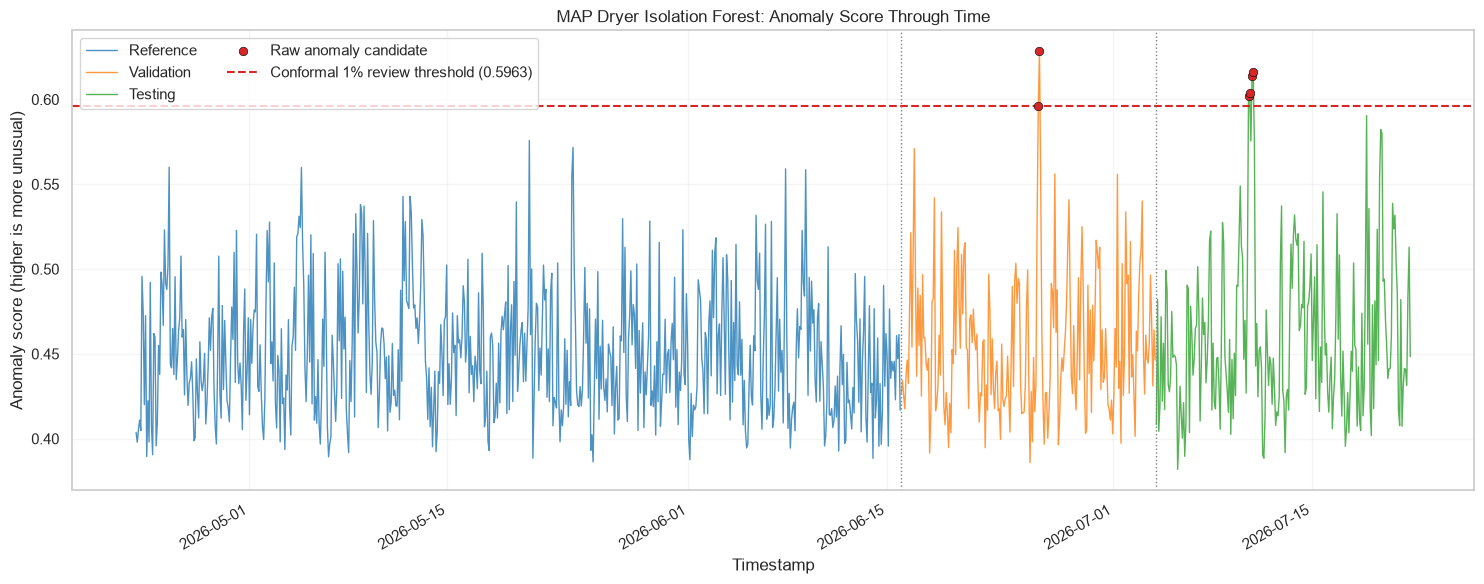

In [14]:
split_colors = {
    "Reference": "tab:blue",
    "Validation": "tab:orange",
    "Testing": "tab:green",
}

fig, axis = plt.subplots(figsize=(15, 6))
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axis.plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1.0,
        alpha=0.8,
        label=split_name,
    )

raw_anomaly_candidates = anomaly_score_results.loc[
    anomaly_score_results["Raw anomaly flag"]
]
axis.scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.4,
    s=38,
    zorder=4,
    label="Raw anomaly candidate",
)
axis.axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Conformal 1% review threshold ({ANOMALY_THRESHOLD:.4f})",
)
axis.axvline(
    validation_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.axvline(
    test_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.set_title("MAP Dryer Isolation Forest: Anomaly Score Through Time")
axis.set_xlabel("Timestamp")
axis.set_ylabel("Anomaly score (higher is more unusual)")
axis.grid(alpha=0.2)
axis.legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "02_anomaly_scores_over_time.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 13. Inspect anomalous operating points

Join every raw anomaly candidate back to its unscaled operating measurements and rank the rows by anomaly score. This table supports engineering review of the actual process state while keeping the score, split, and timestamp attached to each observation.


In [15]:
anomalous_operating_points = (
    anomaly_score_results.loc[
        anomaly_score_results["Raw anomaly flag"],
        ["timestamp", "Split", "Anomaly score"],
    ]
    .merge(
        dryerMAP_model[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Anomaly score", ascending=False)
    .reset_index(drop=True)
)
anomalous_operating_points.insert(
    0, "Candidate rank", np.arange(1, len(anomalous_operating_points) + 1)
)

if anomalous_operating_points[MODEL_FEATURES].isna().any().any():
    raise ValueError("Anomaly candidates could not be matched to all process measurements.")

operating_point_rounding = {
    column: 4 for column in ["Anomaly score", *MODEL_FEATURES]
}
display(anomalous_operating_points.round(operating_point_rounding))
print(f"Raw anomaly candidates available for review: {len(anomalous_operating_points)}")


,Candidate rank,timestamp,Split,Anomaly score,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,1,2026-06-25 19:00:00,Validation,0.6283,139.5,32.5,26.16,10.35,51.8,19.61,-2.17,4.51,1370.0,1.035,41.6,97.9,87.7,2.5275,629.145,2735.595
1,2,2026-07-10 21:00:00,Testing,0.6163,137.3,32.8,25.28,10.57,50.5,19.57,-1.87,4.81,1340.0,1.021,36.0,101.3,86.8,2.3917,660.413,2686.961
2,3,2026-07-10 19:00:00,Testing,0.6138,136.9,33.3,27.00,10.74,49.1,19.78,-2.30,4.85,1392.0,1.024,38.7,98.2,87.8,2.5140,663.965,2707.882
3,4,2026-07-10 15:00:00,Testing,0.6039,137.8,30.0,25.89,10.76,48.9,19.21,-1.85,4.83,1336.0,1.022,36.9,100.9,88.9,2.4061,665.574,2647.138
4,5,2026-07-10 13:00:00,Testing,0.6023,137.8,27.8,26.08,10.86,48.5,18.94,-1.94,4.90,1350.0,1.019,38.4,99.4,89.3,2.4015,675.220,2609.932
5,6,2026-06-25 17:00:00,Validation,0.5963,138.9,31.5,25.59,10.52,50.5,19.21,-1.77,4.87,1337.0,1.021,38.2,100.7,88.4,2.4325,676.443,2668.269


Raw anomaly candidates available for review: 6


## 14. Diagnose contributing variables

Isolation Forest does not provide signed per-feature contributions for an individual prediction. Use each candidate's standardized distance from the normal-reference mean as a transparent diagnostic proxy: the largest absolute standardized deviations identify variables that deserve first inspection. These are investigation cues rather than causal explanations, and correlated engineered features may repeat the same underlying process deviation.


,Candidate rank,timestamp,Split,Anomaly score,Contributor rank,Feature,Signed standardized deviation,Absolute standardized deviation
0,1,2026-06-25 19:00:00,Validation,0.6283,1,vacuum,-3.5510,3.5510
1,1,2026-06-25 19:00:00,Validation,0.6283,2,fan_speed,3.3853,3.3853
2,1,2026-06-25 19:00:00,Validation,0.6283,3,cooler_air_temperature,2.9570,2.9570
3,2,2026-07-10 21:00:00,Testing,0.6163,1,final_product_temp,-3.4573,3.4573
4,2,2026-07-10 21:00:00,Testing,0.6163,2,cooler_air_temperature,3.0542,3.0542
5,2,2026-07-10 21:00:00,Testing,0.6163,3,air_product_delta,-2.7698,2.7698
6,3,2026-07-10 19:00:00,Testing,0.6138,1,fan_speed,4.0731,4.0731
7,3,2026-07-10 19:00:00,Testing,0.6138,2,vacuum,-3.9346,3.9346
8,3,2026-07-10 19:00:00,Testing,0.6138,3,air_flow_rate,3.8875,3.8875
9,4,2026-07-10 15:00:00,Testing,0.6039,1,final_product_temp,-3.0272,3.0272


,Top_three_appearances,Mean_absolute_deviation,Maximum_absolute_deviation
Feature,,,
vacuum,4,3.2412,3.9346
fan_speed,3,3.4061,4.0731
air_flow_rate,3,3.0673,3.8875
final_product_temp,3,2.9635,3.4573
cooler_air_temperature,3,2.8815,3.0542
air_product_delta,1,2.7698,2.7698
temperature_drop,1,2.4097,2.4097


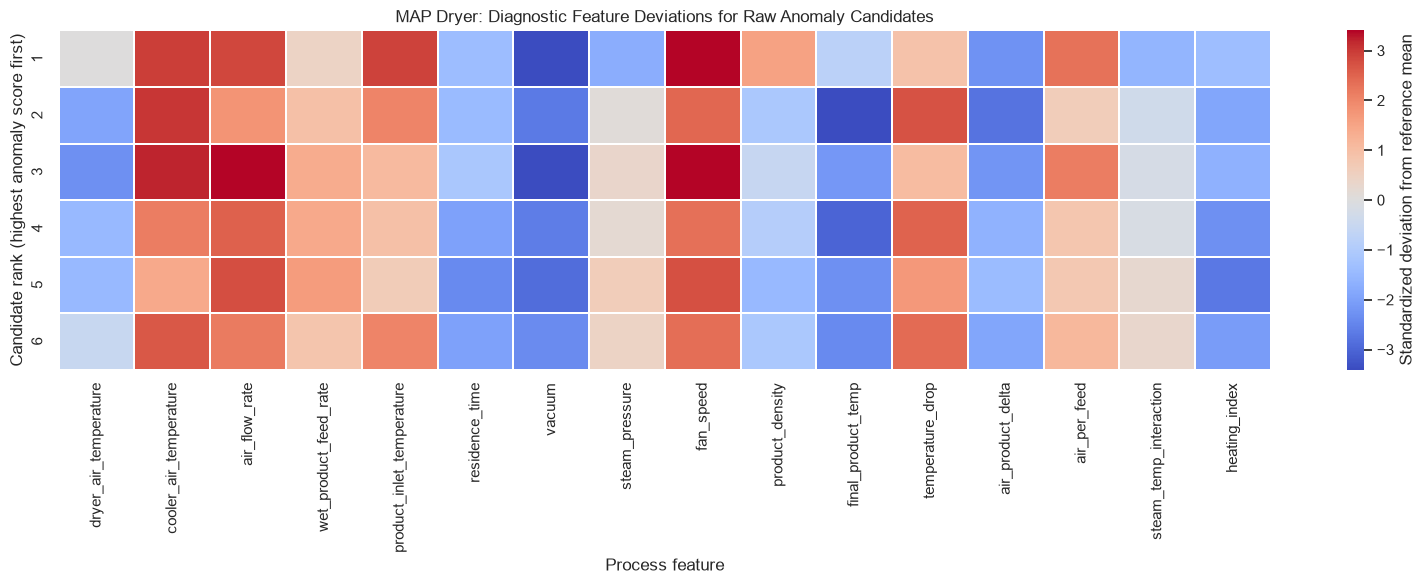

In [16]:
scaled_feature_timeline = (
    pd.concat(
        [
            build_scaled_feature_table(
                MODEL_FEATURES,
                "Reference", train_timestamps, X_train_scaled
            ),
            build_scaled_feature_table(
                MODEL_FEATURES,
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_scaled_feature_table(
                MODEL_FEATURES,
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

candidate_scaled_features = (
    anomalous_operating_points[
        ["Candidate rank", "timestamp", "Split", "Anomaly score"]
    ]
    .merge(
        scaled_feature_timeline[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Candidate rank")
    .reset_index(drop=True)
)

diagnostic_records = []
for _, candidate in candidate_scaled_features.iterrows():
    ordered_features = (
        candidate[MODEL_FEATURES].astype(float).abs().sort_values(ascending=False)
    )
    for contributor_rank, feature in enumerate(ordered_features.index[:3], start=1):
        signed_deviation = float(candidate[feature])
        diagnostic_records.append(
            {
                "Candidate rank": int(candidate["Candidate rank"]),
                "timestamp": candidate["timestamp"],
                "Split": candidate["Split"],
                "Anomaly score": candidate["Anomaly score"],
                "Contributor rank": contributor_rank,
                "Feature": feature,
                "Signed standardized deviation": signed_deviation,
                "Absolute standardized deviation": abs(signed_deviation),
            }
        )

contributing_variable_diagnostics = pd.DataFrame(diagnostic_records)
contributor_summary = (
    contributing_variable_diagnostics.groupby("Feature")
    .agg(
        Top_three_appearances=("Feature", "size"),
        Mean_absolute_deviation=("Absolute standardized deviation", "mean"),
        Maximum_absolute_deviation=("Absolute standardized deviation", "max"),
    )
    .sort_values(
        ["Top_three_appearances", "Mean_absolute_deviation"],
        ascending=False,
    )
)

diagnostic_rounding = {
    "Anomaly score": 4,
    "Signed standardized deviation": 4,
    "Absolute standardized deviation": 4,
}
display(contributing_variable_diagnostics.round(diagnostic_rounding))
display(contributor_summary.round(4))

candidate_heatmap = candidate_scaled_features.set_index("Candidate rank")[
    MODEL_FEATURES
]
heatmap_limit = max(3.0, float(np.nanpercentile(np.abs(candidate_heatmap), 95)))
plt.figure(figsize=(16, max(6, 0.45 * len(candidate_heatmap))))
sns.heatmap(
    candidate_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-heatmap_limit,
    vmax=heatmap_limit,
    linewidths=0.2,
    cbar_kws={"label": "Standardized deviation from reference mean"},
)
plt.title("MAP Dryer: Diagnostic Feature Deviations for Raw Anomaly Candidates")
plt.xlabel("Process feature")
plt.ylabel("Candidate rank (highest anomaly score first)")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_candidate_feature_deviation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 15. Add persistence and alarm logic

Reduce nuisance alarms by requiring at least two raw anomaly candidates within a rolling window of three observations. At the dataset's two-hour sampling interval, this evaluates the current observation and the preceding four hours. A persistent alarm remains active while the rolling condition is satisfied. Persistence state is reset at each artificial train/validation/test boundary so candidates from validation cannot leak into test evaluation; a deployed stream would carry its state continuously.


,Split,Alarm start,Alarm end,Alarm observations,Raw candidates while active,Maximum anomaly score
Alarm episode,,,,,,
1,Validation,2026-06-25 19:00:00,2026-06-25 21:00:00,2,1,0.62833
2,Testing,2026-07-10 15:00:00,2026-07-10 23:00:00,5,3,0.61633


,Observations
Combined alarm state,
Normal within configured PCS7 limits,927
Warning: PCS7 limit,122
Critical: PCS7 limit,23
Critical: PCS7 limit + persistent ML anomaly,3
High: PCS7 warning + persistent ML anomaly,3
Review: raw ML candidate,1
Advisory: persistent ML anomaly,1


Persistence rule: 2 of 3 observations; sample interval = 0 days 02:00:00.


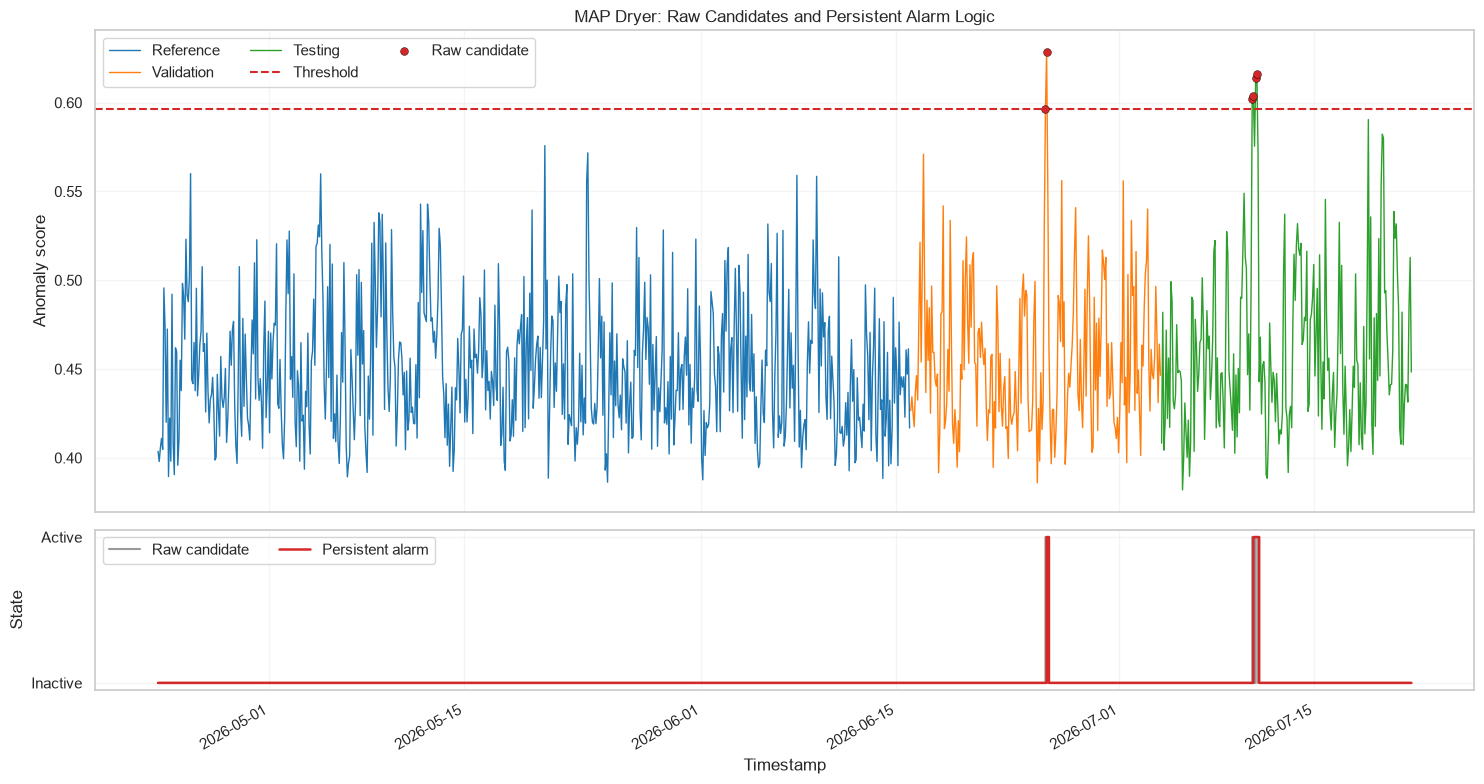

In [17]:
PERSISTENCE_WINDOW_OBSERVATIONS = 3
MINIMUM_CANDIDATES_IN_WINDOW = 2

observed_intervals = (
    anomaly_score_results["timestamp"].sort_values().diff().dropna()
)
EXPECTED_SAMPLE_INTERVAL = observed_intervals.mode().iloc[0]
CADENCE_GAP_TOLERANCE = 1.5
irregular_interval_count = int(
    (observed_intervals > EXPECTED_SAMPLE_INTERVAL * CADENCE_GAP_TOLERANCE).sum()
)
if irregular_interval_count:
    print(
        f"Detected {irregular_interval_count} sampling gaps; persistence state "
        "will reset at each gap."
    )

anomaly_score_results = apply_persistence_logic(
    anomaly_score_results,
    expected_sample_interval=EXPECTED_SAMPLE_INTERVAL,
    cadence_gap_tolerance=CADENCE_GAP_TOLERANCE,
    window_observations=PERSISTENCE_WINDOW_OBSERVATIONS,
    minimum_candidates=MINIMUM_CANDIDATES_IN_WINDOW,
)

anomaly_score_results = attach_pcs7_hybrid_alarm_state(
    anomaly_score_results,
    pcs7_limit_results,
    CONFIGURED_PCS7_LIMIT_COUNT,
)

persistent_alarm_rows = anomaly_score_results.loc[
    anomaly_score_results["Persistent alarm"]
]
if persistent_alarm_rows.empty:
    alarm_event_summary = pd.DataFrame(
        columns=[
            "Split",
            "Alarm start",
            "Alarm end",
            "Alarm observations",
            "Raw candidates while active",
            "Maximum anomaly score",
        ]
    )
else:
    alarm_event_summary = persistent_alarm_rows.groupby("Alarm episode").agg(
        Split=("Split", lambda values: " / ".join(pd.unique(values))),
        Alarm_start=("timestamp", "min"),
        Alarm_end=("timestamp", "max"),
        Alarm_observations=("Persistent alarm", "size"),
        Raw_candidates_while_active=("Raw anomaly flag", "sum"),
        Maximum_anomaly_score=("Anomaly score", "max"),
    )
    alarm_event_summary.columns = [
        "Split",
        "Alarm start",
        "Alarm end",
        "Alarm observations",
        "Raw candidates while active",
        "Maximum anomaly score",
    ]

hybrid_state_summary = (
    anomaly_score_results["Combined alarm state"]
    .value_counts()
    .rename_axis("Combined alarm state")
    .to_frame("Observations")
)
display(alarm_event_summary.round({"Maximum anomaly score": 5}))
display(hybrid_state_summary)
print(
    f"Persistence rule: {MINIMUM_CANDIDATES_IN_WINDOW} of "
    f"{PERSISTENCE_WINDOW_OBSERVATIONS} observations; "
    f"sample interval = {EXPECTED_SAMPLE_INTERVAL}."
)

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(ANOMALY_THRESHOLD, color="tab:red", linestyle="--", label="Threshold")
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw candidate",
)
axes[0].set_ylabel("Anomaly score")
axes[0].set_title("MAP Dryer: Raw Candidates and Persistent Alarm Logic")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Raw anomaly flag"].astype(int),
    where="post",
    color="grey",
    alpha=0.8,
    label="Raw candidate",
)
axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Persistent alarm"].astype(int),
    where="post",
    color="tab:red",
    linewidth=1.8,
    label="Persistent alarm",
)
axes[1].set_yticks([0, 1], labels=["Inactive", "Active"])
axes[1].set_ylabel("State")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "04_persistent_alarm_logic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Hybrid PCS7 and machine-learning alarm timeline

Keep deterministic PCS7 rule status separate from the statistical ML signal, then combine them into a prioritized state. Critical PCS7 violations have the highest priority, followed by simultaneous PCS7 warnings and persistent ML anomalies, standalone PCS7 warnings, persistent ML advisories, and isolated raw ML candidates. Until limits are configured, the PCS7 component remains visibly disabled rather than silently treating observations as in-limit.


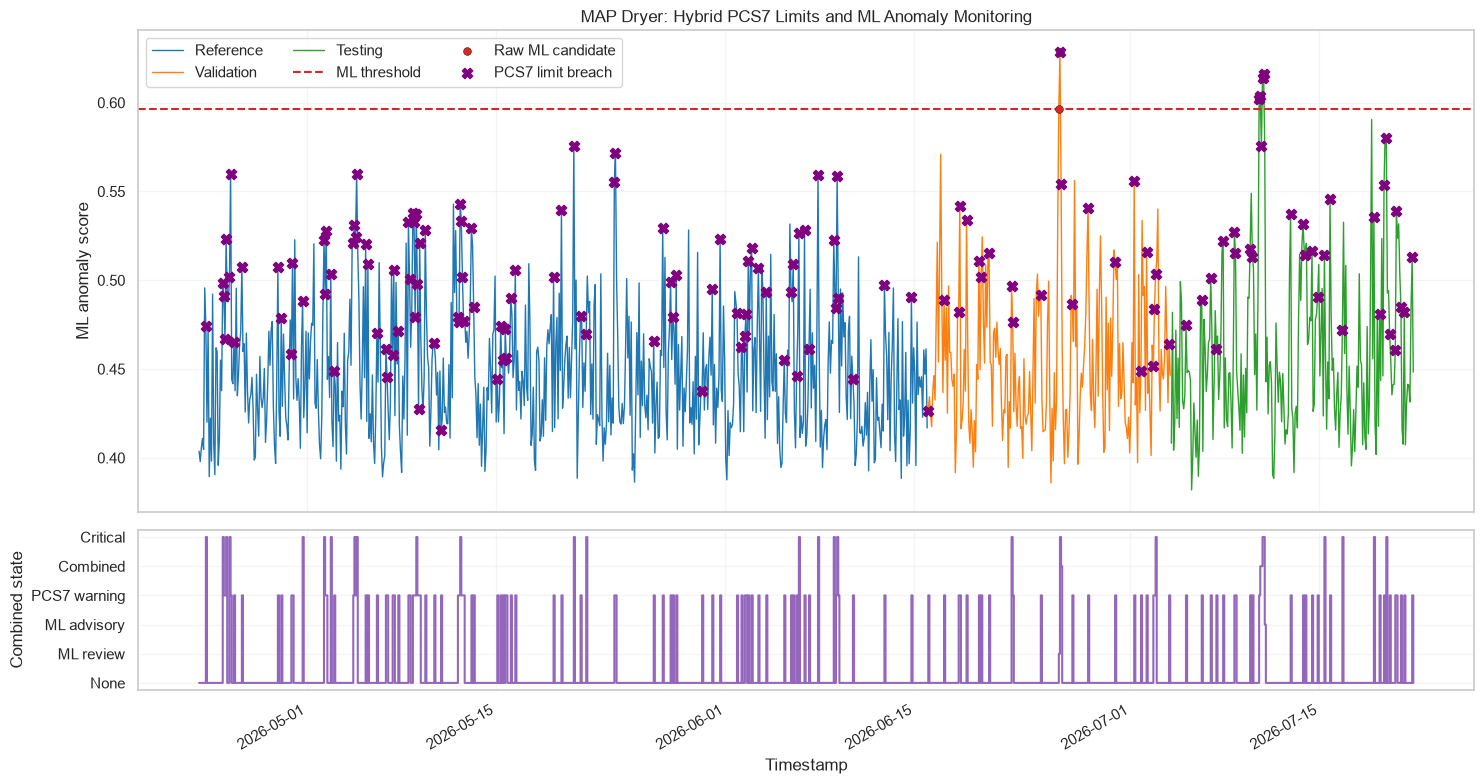

In [18]:
pcs7_breach_points = anomaly_score_results.loc[
    anomaly_score_results["PCS7 rule breach"]
]

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label="ML threshold",
)
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw ML candidate",
)
if not pcs7_breach_points.empty:
    axes[0].scatter(
        pcs7_breach_points["timestamp"],
        pcs7_breach_points["Anomaly score"],
        color="purple",
        marker="X",
        s=55,
        zorder=5,
        label="PCS7 limit breach",
    )
axes[0].set_title("MAP Dryer: Hybrid PCS7 Limits and ML Anomaly Monitoring")
axes[0].set_ylabel("ML anomaly score")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Combined severity level"],
    where="post",
    color="tab:purple",
    linewidth=1.5,
)
axes[1].set_yticks(
    [0, 1, 2, 3, 4, 5],
    labels=["None", "ML review", "ML advisory", "PCS7 warning", "Combined", "Critical"],
)
axes[1].set_ylabel("Combined state")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "05_hybrid_pcs7_ml_alarm_timeline.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "Hybrid timeline prepared: PCS7 breach markers remain disabled until limits are configured."
    )


## 16. Evaluate the model

Confirmed anomaly labels are not available, so supervised metrics such as precision, recall, and ROC AUC cannot be reported honestly. Evaluate the baseline detector using four complementary proxies: alert burden by chronological split, score drift, feature-level drift, and sensitivity to a suite of controlled synthetic deviations applied only to validation data. Synthetic faults modify direct measurements in original engineering units and then recompute all dependent engineered features, avoiding the physically inconsistent rows produced by independently shifting derived columns. These tests measure sensitivity, not real-world accuracy.


In [19]:
split_evaluation = anomaly_score_results.groupby("Split", sort=False).agg(
    Observations=("Anomaly score", "size"),
    Median_score=("Anomaly score", "median"),
    Score_95th_percentile=("Anomaly score", lambda values: values.quantile(0.95)),
    Raw_candidates=("Raw anomaly flag", "sum"),
    Persistent_alarm_observations=("Persistent alarm", "sum"),
    Persistent_alarm_episodes=("Alarm episode", "nunique"),
)
split_evaluation["Raw candidate rate (%)"] = (
    100 * split_evaluation["Raw_candidates"] / split_evaluation["Observations"]
)
split_evaluation["Persistent alarm rate (%)"] = (
    100
    * split_evaluation["Persistent_alarm_observations"]
    / split_evaluation["Observations"]
)

reference_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Reference", "Anomaly score"
]
score_drift_rows = []
for later_split in ["Validation", "Testing"]:
    later_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == later_split, "Anomaly score"
    ]
    drift_test = ks_2samp(reference_score_values, later_scores)
    score_drift_rows.append(
        {
            "Comparison": f"Reference vs {later_split}",
            "KS statistic": drift_test.statistic,
            "p-value": drift_test.pvalue,
            "Median score change": (
                later_scores.median() - reference_score_values.median()
            ),
        }
    )
score_drift_evaluation = pd.DataFrame(score_drift_rows).set_index("Comparison")

feature_drift_rows = []
for feature in MODEL_FEATURES:
    reference_values = X_normal_reference[feature]
    reference_scale = max(float(reference_values.std(ddof=0)), 1e-12)
    validation_drift = ks_2samp(reference_values, X_validation[feature])
    test_drift = ks_2samp(reference_values, X_test[feature])
    feature_drift_rows.append(
        {
            "Feature": feature,
            "Validation KS statistic": validation_drift.statistic,
            "Validation median shift (reference SD)": (
                X_validation[feature].median() - reference_values.median()
            ) / reference_scale,
            "Test KS statistic - descriptive": test_drift.statistic,
            "Test median shift (reference SD) - descriptive": (
                X_test[feature].median() - reference_values.median()
            ) / reference_scale,
        }
    )
feature_drift_evaluation = (
    pd.DataFrame(feature_drift_rows)
    .set_index("Feature")
    .sort_values("Validation KS statistic", ascending=False)
)

SYNTHETIC_SCENARIO_SPECIFICATIONS = {
    "Single sensor bias (3 reference SD)": (1, 3.0, 55),
    "Single sensor bias (4 reference SD)": (1, 4.0, 60),
    "Two-variable excursion (2 reference SD)": (2, 2.0, 66),
    "Two-variable excursion (3 reference SD)": (2, 3.0, 68),
    "Three-variable excursion (2 reference SD)": (3, 2.0, 76),
    "Three-variable excursion (3 reference SD)": (3, 3.0, 78),
    "Three-variable excursion (4 reference SD)": (3, 4.0, 80),
}
synthetic_validation_scenarios_scaled = {
    scenario_name: build_synthetic_validation_scenario(
        X_validation,
        X_normal_reference,
        DIRECT_PROCESS_FEATURES,
        MODEL_FEATURES,
        anomaly_scaler,
        *scenario_parameters,
    )
    for scenario_name, scenario_parameters in SYNTHETIC_SCENARIO_SPECIFICATIONS.items()
}
baseline_synthetic_scenario_detection = pd.Series(
    {
        scenario_name: np.mean(
            -isolation_forest_model.score_samples(scenario_features)
            >= ANOMALY_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Baseline Isolation Forest detection rate",
)
baseline_synthetic_detection_rate = float(
    baseline_synthetic_scenario_detection.mean()
)

baseline_evaluation_summary = pd.Series(
    {
        "Validation raw candidate rate (%)": split_evaluation.loc[
            "Validation", "Raw candidate rate (%)"
        ],
        "Validation persistent alarm episodes": split_evaluation.loc[
            "Validation", "Persistent_alarm_episodes"
        ],
        "Mean synthetic scenario detection rate (%)": (
            100 * baseline_synthetic_detection_rate
        ),
        "Test raw candidate rate (%) - descriptive only": split_evaluation.loc[
            "Testing", "Raw candidate rate (%)"
        ],
        "Test persistent alarm episodes - descriptive only": split_evaluation.loc[
            "Testing", "Persistent_alarm_episodes"
        ],
    },
    name="Baseline Isolation Forest",
)

if CONFIGURED_PCS7_LIMIT_COUNT > 0:
    pcs7_breach_mask = anomaly_score_results["PCS7 rule breach"]
    pcs7_breach_count = int(pcs7_breach_mask.sum())
    pcs7_ml_agreement = pd.crosstab(
        anomaly_score_results["PCS7 limit status"],
        anomaly_score_results["Persistent alarm"],
        rownames=["PCS7 status"],
        colnames=["Persistent ML alarm"],
    )
    pcs7_ml_comparison = pd.Series(
        {
            "Configured PCS7 limit breaches": pcs7_breach_count,
            "PCS7 breaches also detected as raw ML candidates (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Raw anomaly flag"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "PCS7 breaches also detected as persistent ML alarms (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Persistent alarm"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "Raw ML candidates without a PCS7 breach": int(
                (
                    anomaly_score_results["Raw anomaly flag"]
                    & ~pcs7_breach_mask
                ).sum()
            ),
        },
        name="PCS7 and ML comparison",
    )
else:
    pcs7_ml_agreement = pd.DataFrame(
        {
            "Status": [
                "Unavailable because no prototype limits are configured."
            ]
        }
    )
    pcs7_ml_comparison = pd.Series(
        {"Configured PCS7 limits": 0},
        name="PCS7 and ML comparison",
    )

display(split_evaluation.round(4))
display(score_drift_evaluation.round(5))
display(feature_drift_evaluation.round(4))
display((100 * baseline_synthetic_scenario_detection).to_frame().round(2))
display(baseline_evaluation_summary.to_frame().round(4))
display(pcs7_ml_agreement)
display(pcs7_ml_comparison.to_frame().round(4))
print(
    "The tables report candidate burden, persistence, distribution shift, "
    "and scenario sensitivity as separate prototype checks."
)


,Observations,Median_score,Score_95th_percentile,Raw_candidates,Persistent_alarm_observations,Persistent_alarm_episodes,Raw candidate rate (%),Persistent alarm rate (%)
Split,,,,,,,,
Reference,648,0.4452,0.5209,0,0,0,0.0000,0.0000
Validation,216,0.4478,0.5314,2,2,1,0.9259,0.9259
Testing,216,0.4486,0.5464,4,5,1,1.8519,2.3148


,KS statistic,p-value,Median score change
Comparison,,,
Reference vs Validation,0.07716,0.28265,0.00261
Reference vs Testing,0.10031,0.07417,0.00340


,Validation KS statistic,Validation median shift (reference SD),Test KS statistic - descriptive,Test median shift (reference SD) - descriptive
Feature,,,,
cooler_air_temperature,0.1991,0.5345,0.2793,0.8260
air_per_feed,0.1806,0.3757,0.2191,0.4784
residence_time,0.1497,0.2688,0.0972,-0.1867
final_product_temp,0.1466,-0.2867,0.1975,-0.4301
wet_product_feed_rate,0.1404,-0.3259,0.0664,0.0121
product_density,0.1281,-0.1896,0.0694,-0.1896
air_product_delta,0.1265,-0.2967,0.1806,-0.4316
temperature_drop,0.1219,0.2700,0.2238,0.4860
steam_pressure,0.1157,-0.2719,0.0571,0.0000


,Baseline Isolation Forest detection rate
Single sensor bias (3 reference SD),0.93
Single sensor bias (4 reference SD),2.78
Two-variable excursion (2 reference SD),2.78
Two-variable excursion (3 reference SD),4.63
Three-variable excursion (2 reference SD),9.72
Three-variable excursion (3 reference SD),19.44
Three-variable excursion (4 reference SD),25.00


,Baseline Isolation Forest
Validation raw candidate rate (%),0.9259
Validation persistent alarm episodes,1.0000
Mean synthetic scenario detection rate (%),9.3254
Test raw candidate rate (%) - descriptive only,1.8519
Test persistent alarm episodes - descriptive only,1.0000


Persistent ML alarm,False,True
PCS7 status,,
Critical,23,3
Warning,122,3
Within configured limits,928,1


,PCS7 and ML comparison
Configured PCS7 limit breaches,151.0000
PCS7 breaches also detected as raw ML candidates (%),3.3113
PCS7 breaches also detected as persistent ML alarms (%),3.9735
Raw ML candidates without a PCS7 breach,1.0000


The tables report candidate burden, persistence, distribution shift, and scenario sensitivity as separate prototype checks.


## 17. Tune Isolation Forest hyperparameters

Tune the number of trees, samples per tree, and fraction of features per tree. Every candidate is fitted only on the normal reference period and calibrated with the same finite-sample validation rule. Rank configurations first by worst-case and then mean sensitivity across the physically consistent synthetic scenario suite, followed by lower reference candidate rate and score stability. This is more robust than optimizing one artificial disturbance. The test period is not used to select the configuration.


In [20]:
ISOLATION_FOREST_TUNING_GRID = {
    "n_estimators": [200, 300, 500],
    "max_samples": sorted(
        {128, 256, min(512, len(X_normal_reference_scaled)), len(X_normal_reference_scaled)}
    ),
    "max_features": [0.50, 0.75, 1.0],
}

baseline_validation_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation", "Anomaly score"
].to_numpy()

tuning_rows = []
for n_estimators, max_samples, max_features in product(
    ISOLATION_FOREST_TUNING_GRID["n_estimators"],
    ISOLATION_FOREST_TUNING_GRID["max_samples"],
    ISOLATION_FOREST_TUNING_GRID["max_features"],
):
    candidate_model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination="auto",
        max_features=max_features,
        bootstrap=False,
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(X_normal_reference_scaled)

    candidate_reference_scores = -candidate_model.score_samples(
        X_normal_reference_scaled
    )
    candidate_validation_scores = -candidate_model.score_samples(
        X_validation_scaled
    )
    candidate_threshold, _ = calibrate_conformal_threshold(
        candidate_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
    candidate_synthetic_detection_rates = [
        np.mean(
            -candidate_model.score_samples(scenario_features)
            >= candidate_threshold
        )
        for scenario_features in synthetic_validation_scenarios_scaled.values()
    ]
    score_stability = spearmanr(
        baseline_validation_score_values, candidate_validation_scores
    ).statistic

    tuning_rows.append(
        {
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "max_features": max_features,
            "Validation threshold": candidate_threshold,
            "Reference candidate rate (%)": (
                100 * np.mean(candidate_reference_scores >= candidate_threshold)
            ),
            "Validation candidate rate (%)": (
                100 * np.mean(candidate_validation_scores >= candidate_threshold)
            ),
            "Worst synthetic detection rate (%)": (
                100 * np.min(candidate_synthetic_detection_rates)
            ),
            "Mean synthetic detection rate (%)": (
                100 * np.mean(candidate_synthetic_detection_rates)
            ),
            "Score stability vs baseline": score_stability,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "Worst synthetic detection rate (%)",
            "Mean synthetic detection rate (%)",
            "Reference candidate rate (%)",
            "Score stability vs baseline",
            "n_estimators",
        ],
        ascending=[False, False, True, False, True],
    )
    .reset_index(drop=True)
)

best_tuning_row = tuning_results.iloc[0]
best_isolation_forest_parameters = {
    "n_estimators": int(best_tuning_row["n_estimators"]),
    "max_samples": int(best_tuning_row["max_samples"]),
    "max_features": float(best_tuning_row["max_features"]),
}

selected_isolation_forest_model = IsolationForest(
    **best_isolation_forest_parameters,
    contamination="auto",
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
selected_isolation_forest_model.fit(X_normal_reference_scaled)

selected_anomaly_score_results = (
    pd.concat(
        [
            build_anomaly_score_table(selected_isolation_forest_model, MODEL_FEATURES, 
                "Reference", train_timestamps, X_train_scaled
            ),
            build_anomaly_score_table(selected_isolation_forest_model, MODEL_FEATURES, 
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_anomaly_score_table(selected_isolation_forest_model, MODEL_FEATURES, 
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

selected_validation_scores = selected_anomaly_score_results.loc[
    selected_anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
SELECTED_ANOMALY_THRESHOLD, SELECTED_THRESHOLD_ORDER_RANK = (
    calibrate_conformal_threshold(
        selected_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
)
selected_anomaly_score_results["Raw anomaly flag"] = (
    selected_anomaly_score_results["Anomaly score"]
    >= SELECTED_ANOMALY_THRESHOLD
)
selected_anomaly_score_results = apply_persistence_logic(
    selected_anomaly_score_results,
    expected_sample_interval=EXPECTED_SAMPLE_INTERVAL,
    cadence_gap_tolerance=CADENCE_GAP_TOLERANCE,
    window_observations=PERSISTENCE_WINDOW_OBSERVATIONS,
    minimum_candidates=MINIMUM_CANDIDATES_IN_WINDOW,
)
selected_anomaly_score_results = attach_pcs7_hybrid_alarm_state(
    selected_anomaly_score_results,
    pcs7_limit_results,
    CONFIGURED_PCS7_LIMIT_COUNT,
)

selected_isolation_forest_synthetic_detection = pd.Series(
    {
        scenario_name: np.mean(
            -selected_isolation_forest_model.score_samples(scenario_features)
            >= SELECTED_ANOMALY_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Selected Isolation Forest",
)
selected_synthetic_detection_rate = float(
    selected_isolation_forest_synthetic_detection.mean()
)

baseline_vs_selected_comparison = pd.DataFrame(
    {
        "Baseline Isolation Forest": {
            "Trees": isolation_forest_model.n_estimators,
            "Maximum samples": isolation_forest_model.max_samples_,
            "Maximum feature fraction": isolation_forest_model.max_features,
            "Validation threshold": ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                anomaly_score_results, "Validation"
            ),
            "Mean synthetic detection rate (%)": (
                100 * baseline_synthetic_detection_rate
            ),
        },
        "Selected Isolation Forest": {
            "Trees": selected_isolation_forest_model.n_estimators,
            "Maximum samples": selected_isolation_forest_model.max_samples_,
            "Maximum feature fraction": selected_isolation_forest_model.max_features,
            "Validation threshold": SELECTED_ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Validation"
            ),
            "Mean synthetic detection rate (%)": (
                100 * selected_synthetic_detection_rate
            ),
        },
    }
)

display(tuning_results.round(5))
display(baseline_vs_selected_comparison.round(5))
display((100 * selected_isolation_forest_synthetic_detection).to_frame().round(2))
print("Selected parameters:", best_isolation_forest_parameters)
print(f"Selected validation threshold: {SELECTED_ANOMALY_THRESHOLD:.5f}")
print("The test period was not used to rank or select hyperparameters.")


,n_estimators,max_samples,max_features,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Worst synthetic detection rate (%),Mean synthetic detection rate (%),Score stability vs baseline
0,200,128,0.75,0.57647,0.46296,0.92593,3.24074,16.13757,0.96673
1,300,128,0.75,0.58339,0.15432,0.92593,3.24074,12.63228,0.97347
2,200,512,0.75,0.57628,0.15432,0.92593,2.77778,22.61905,0.97364
3,500,512,1.00,0.58047,0.15432,0.92593,2.31481,19.24603,0.98537
4,200,648,0.50,0.58484,0.15432,0.92593,1.85185,21.36243,0.96864
5,300,648,0.75,0.58374,0.00000,0.92593,1.85185,20.43651,0.97766
6,300,512,1.00,0.58897,0.00000,0.92593,1.85185,14.81481,0.98224
7,300,256,0.75,0.58375,0.00000,0.92593,1.85185,14.35185,0.98043
8,500,256,0.75,0.58567,0.00000,0.92593,1.85185,13.75661,0.98148
9,500,648,0.75,0.58083,0.00000,0.92593,1.38889,22.68519,0.98188


,Baseline Isolation Forest,Selected Isolation Forest
Trees,300.00000,200.00000
Maximum samples,256.00000,128.00000
Maximum feature fraction,1.00000,0.75000
Validation threshold,0.59630,0.57647
Reference candidate rate (%),0.00000,0.46296
Validation candidate rate (%),0.92593,0.92593
Mean synthetic detection rate (%),9.32540,16.13757


,Selected Isolation Forest
Single sensor bias (3 reference SD),3.24
Single sensor bias (4 reference SD),4.17
Two-variable excursion (2 reference SD),5.56
Two-variable excursion (3 reference SD),11.57
Three-variable excursion (2 reference SD),19.44
Three-variable excursion (3 reference SD),30.56
Three-variable excursion (4 reference SD),38.43


Selected parameters: {'n_estimators': 200, 'max_samples': 128, 'max_features': 0.75}
Selected validation threshold: 0.57647
The test period was not used to rank or select hyperparameters.


## 18. Compare Isolation Forest with One-Class SVM

Compare the tuned Isolation Forest and RBF One-Class SVM using the same chronological reference, validation split, scenario suite, and persistence rule. Each detector retains its own score scale and threshold. The primary detector is selected from the validation candidate burden and scenario sensitivity summaries.


,gamma,nu,Validation threshold,Reference candidate rate (%),Worst synthetic detection rate (%),Mean synthetic detection rate (%)
0,scale,0.020,-0.63416,0.00000,62.96296,87.30159
1,scale,0.005,-0.15845,0.00000,62.96296,87.23545
2,scale,0.010,-0.31702,0.00000,62.96296,87.23545
3,scale,0.050,-1.59769,0.00000,62.03704,86.83862
4,0.1,0.010,-0.10483,0.00000,59.25926,86.37566
5,0.1,0.020,-0.20946,0.00000,59.25926,86.37566
6,0.1,0.050,-0.52373,0.00000,59.25926,86.30952
7,0.05,0.005,-0.23412,0.00000,59.25926,85.18519
8,0.05,0.010,-0.46787,0.00000,59.25926,85.18519
9,0.05,0.020,-0.93599,0.00000,59.25926,85.18519


,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Validation persistent episodes,Worst synthetic detection rate (%),Mean synthetic detection rate (%),Test candidate rate (%) - descriptive,Test persistent episodes - descriptive
Detector,,,,,,,,
Selected Isolation Forest,0.57647,0.46296,0.92593,1,3.24074,16.13757,2.77778,1
Tuned One-Class SVM,-0.63416,0.00000,0.92593,0,62.96296,87.30159,2.31481,1


,Selected Isolation Forest,Tuned One-Class SVM
Single sensor bias (3 reference SD),3.24,62.96
Single sensor bias (4 reference SD),4.17,94.44
Two-variable excursion (2 reference SD),5.56,64.35
Two-variable excursion (3 reference SD),11.57,98.61
Three-variable excursion (2 reference SD),19.44,90.74
Three-variable excursion (3 reference SD),30.56,100.00
Three-variable excursion (4 reference SD),38.43,100.00


Agreement category,Both detectors,Isolation Forest only,Neither detector,One-Class SVM only
Split,,,,
Reference,0,3,645,0
Testing,2,4,207,3
Validation,1,1,213,1


Validation score-rank correlation: 0.898
Selected One-Class SVM parameters: {'gamma': 'scale', 'nu': 0.02}
Provisional primary detector: Tuned One-Class SVM
Selection uses validation candidate burden and scenario sensitivity.


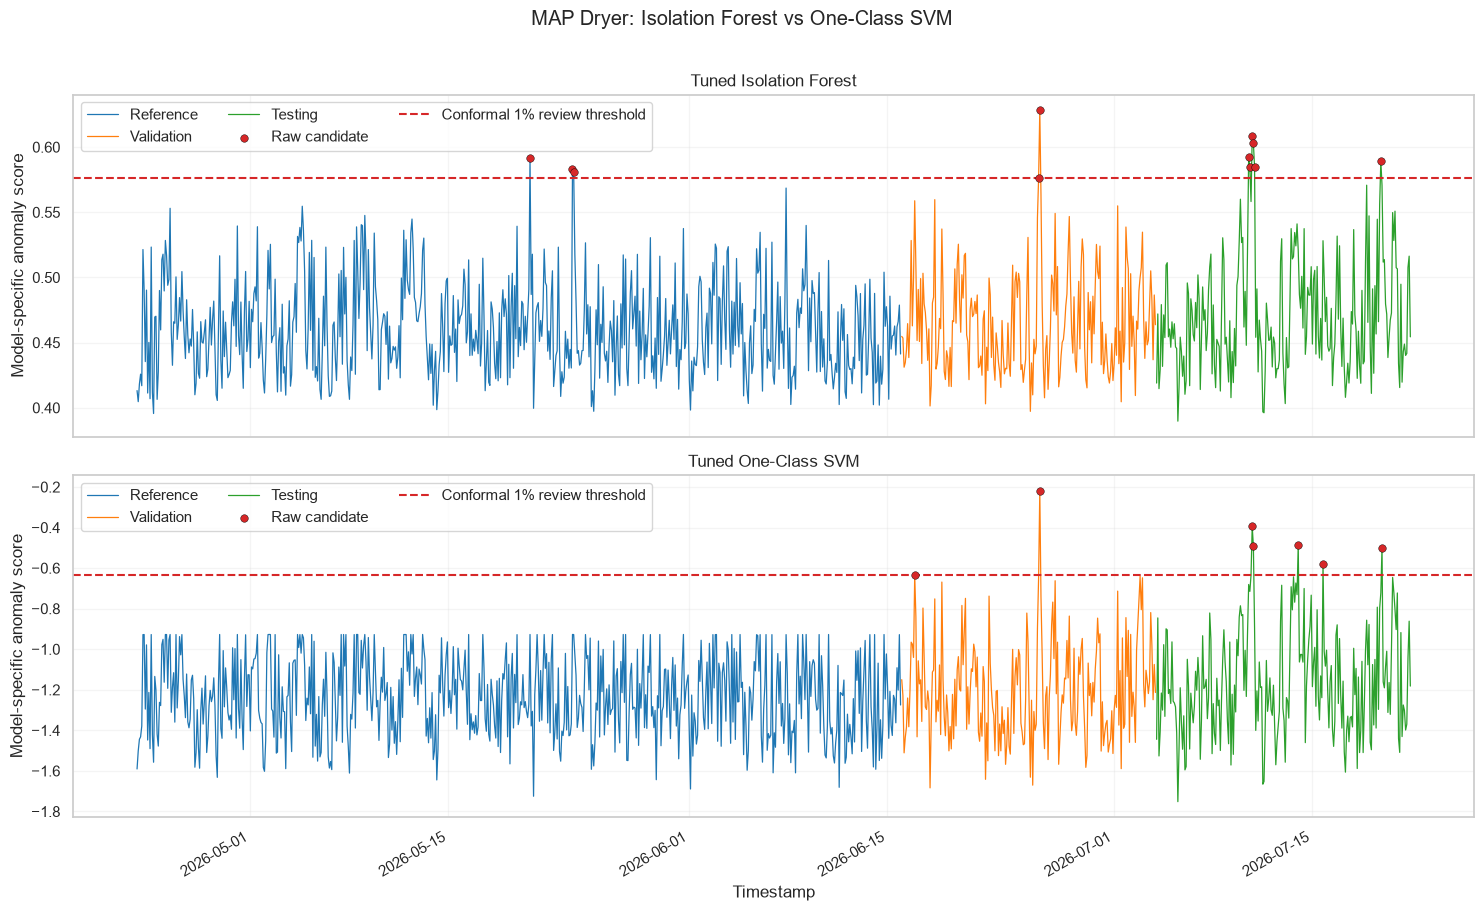

In [21]:
ONE_CLASS_SVM_TUNING_GRID = {
    "gamma": ["scale", 0.03, 0.05, 0.10],
    "nu": [0.005, 0.01, 0.02, 0.05],
}
one_class_svm_tuning_rows = []
for gamma_value, nu_value in product(
    ONE_CLASS_SVM_TUNING_GRID["gamma"],
    ONE_CLASS_SVM_TUNING_GRID["nu"],
):
    candidate_svm = OneClassSVM(
        kernel="rbf", gamma=gamma_value, nu=nu_value
    ).fit(X_normal_reference_scaled)
    candidate_reference_scores = -candidate_svm.score_samples(
        X_normal_reference_scaled
    )
    candidate_validation_scores = -candidate_svm.score_samples(
        X_validation_scaled
    )
    candidate_threshold, _ = calibrate_conformal_threshold(
        candidate_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
    scenario_detection_rates = [
        np.mean(
            -candidate_svm.score_samples(scenario_features)
            >= candidate_threshold
        )
        for scenario_features in synthetic_validation_scenarios_scaled.values()
    ]
    one_class_svm_tuning_rows.append(
        {
            "gamma": gamma_value,
            "nu": nu_value,
            "Validation threshold": candidate_threshold,
            "Reference candidate rate (%)": 100 * np.mean(
                candidate_reference_scores >= candidate_threshold
            ),
            "Worst synthetic detection rate (%)": 100 * np.min(
                scenario_detection_rates
            ),
            "Mean synthetic detection rate (%)": 100 * np.mean(
                scenario_detection_rates
            ),
        }
    )

one_class_svm_tuning_results = (
    pd.DataFrame(one_class_svm_tuning_rows)
    .sort_values(
        [
            "Worst synthetic detection rate (%)",
            "Mean synthetic detection rate (%)",
            "Reference candidate rate (%)",
            "nu",
        ],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)
best_svm_tuning_row = one_class_svm_tuning_results.iloc[0]
best_one_class_svm_parameters = {
    "gamma": best_svm_tuning_row["gamma"],
    "nu": float(best_svm_tuning_row["nu"]),
}
one_class_svm_model = OneClassSVM(
    kernel="rbf", **best_one_class_svm_parameters
)
one_class_svm_model.fit(X_normal_reference_scaled)

one_class_svm_score_results = (
    pd.concat(
        [
            build_anomaly_score_table(one_class_svm_model, MODEL_FEATURES, 
                "Reference", train_timestamps, X_train_scaled
            ),
            build_anomaly_score_table(one_class_svm_model, MODEL_FEATURES, 
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_anomaly_score_table(one_class_svm_model, MODEL_FEATURES, 
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

one_class_svm_validation_scores = one_class_svm_score_results.loc[
    one_class_svm_score_results["Split"] == "Validation",
    "Anomaly score",
]
ONE_CLASS_SVM_THRESHOLD, ONE_CLASS_SVM_THRESHOLD_ORDER_RANK = (
    calibrate_conformal_threshold(
        one_class_svm_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
)
one_class_svm_score_results["Raw anomaly flag"] = (
    one_class_svm_score_results["Anomaly score"] >= ONE_CLASS_SVM_THRESHOLD
)
one_class_svm_score_results = apply_persistence_logic(
    one_class_svm_score_results,
    expected_sample_interval=EXPECTED_SAMPLE_INTERVAL,
    cadence_gap_tolerance=CADENCE_GAP_TOLERANCE,
    window_observations=PERSISTENCE_WINDOW_OBSERVATIONS,
    minimum_candidates=MINIMUM_CANDIDATES_IN_WINDOW,
)
one_class_svm_score_results = attach_pcs7_hybrid_alarm_state(
    one_class_svm_score_results,
    pcs7_limit_results,
    CONFIGURED_PCS7_LIMIT_COUNT,
)

one_class_svm_synthetic_detection = pd.Series(
    {
        scenario_name: np.mean(
            -one_class_svm_model.score_samples(scenario_features)
            >= ONE_CLASS_SVM_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Tuned One-Class SVM",
)
one_class_svm_synthetic_detection_rate = float(
    one_class_svm_synthetic_detection.mean()
)
synthetic_detector_comparison = 100 * pd.concat(
    [
        selected_isolation_forest_synthetic_detection,
        one_class_svm_synthetic_detection,
    ],
    axis=1,
)

detector_comparison = pd.DataFrame(
    [
        detector_comparison_row(
            "Selected Isolation Forest",
            selected_anomaly_score_results,
            SELECTED_ANOMALY_THRESHOLD,
            selected_isolation_forest_synthetic_detection,
        ),
        detector_comparison_row(
            "Tuned One-Class SVM",
            one_class_svm_score_results,
            ONE_CLASS_SVM_THRESHOLD,
            one_class_svm_synthetic_detection,
        ),
    ]
).set_index("Detector")

detector_flag_agreement = (
    selected_anomaly_score_results[
        ["timestamp", "Split", "Raw anomaly flag"]
    ]
    .rename(columns={"Raw anomaly flag": "Isolation Forest flag"})
    .merge(
        one_class_svm_score_results[
            ["timestamp", "Raw anomaly flag"]
        ].rename(columns={"Raw anomaly flag": "One-Class SVM flag"}),
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )
)
detector_flag_agreement["Agreement category"] = np.select(
    [
        detector_flag_agreement["Isolation Forest flag"]
        & detector_flag_agreement["One-Class SVM flag"],
        detector_flag_agreement["Isolation Forest flag"],
        detector_flag_agreement["One-Class SVM flag"],
    ],
    ["Both detectors", "Isolation Forest only", "One-Class SVM only"],
    default="Neither detector",
)
detector_agreement_summary = pd.crosstab(
    detector_flag_agreement["Split"],
    detector_flag_agreement["Agreement category"],
)

validation_score_comparison = (
    selected_anomaly_score_results.loc[
        selected_anomaly_score_results["Split"] == "Validation",
        ["timestamp", "Anomaly score"],
    ]
    .rename(columns={"Anomaly score": "Isolation Forest score"})
    .merge(
        one_class_svm_score_results.loc[
            one_class_svm_score_results["Split"] == "Validation",
            ["timestamp", "Anomaly score"],
        ].rename(columns={"Anomaly score": "One-Class SVM score"}),
        on="timestamp",
        validate="one_to_one",
    )
)
detector_validation_rank_correlation = spearmanr(
    validation_score_comparison["Isolation Forest score"],
    validation_score_comparison["One-Class SVM score"],
).statistic

provisional_detector_ranking = detector_comparison.sort_values(
    [
        "Worst synthetic detection rate (%)",
        "Mean synthetic detection rate (%)",
        "Reference candidate rate (%)",
    ],
    ascending=[False, False, True],
)
PROVISIONAL_SELECTED_DETECTOR = provisional_detector_ranking.index[0]
if PROVISIONAL_SELECTED_DETECTOR == "Tuned One-Class SVM":
    provisional_selected_model = one_class_svm_model
    PROVISIONAL_SELECTED_THRESHOLD = ONE_CLASS_SVM_THRESHOLD
    provisional_selected_score_results = one_class_svm_score_results.copy()
    provisional_selected_synthetic_detection = (
        one_class_svm_synthetic_detection.copy()
    )
else:
    provisional_selected_model = selected_isolation_forest_model
    PROVISIONAL_SELECTED_THRESHOLD = SELECTED_ANOMALY_THRESHOLD
    provisional_selected_score_results = selected_anomaly_score_results.copy()
    provisional_selected_synthetic_detection = (
        selected_isolation_forest_synthetic_detection.copy()
    )

display(one_class_svm_tuning_results.round(5))
display(detector_comparison.round(5))
display(synthetic_detector_comparison.round(2))
display(detector_agreement_summary)
print(
    f"Validation score-rank correlation: "
    f"{detector_validation_rank_correlation:.3f}"
)
print("Selected One-Class SVM parameters:", best_one_class_svm_parameters)
print("Provisional primary detector:", PROVISIONAL_SELECTED_DETECTOR)
print(
    "Selection uses validation candidate burden and scenario sensitivity."
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
detector_plot_settings = [
    (
        axes[0],
        selected_anomaly_score_results,
        SELECTED_ANOMALY_THRESHOLD,
        "Tuned Isolation Forest",
    ),
    (
        axes[1],
        one_class_svm_score_results,
        ONE_CLASS_SVM_THRESHOLD,
        "Tuned One-Class SVM",
    ),
]
for axis, score_table, threshold, detector_title in detector_plot_settings:
    for split_name, split_color in split_colors.items():
        split_scores = score_table.loc[score_table["Split"] == split_name]
        axis.plot(
            split_scores["timestamp"],
            split_scores["Anomaly score"],
            color=split_color,
            linewidth=0.9,
            label=split_name,
        )
    detector_candidates = score_table.loc[score_table["Raw anomaly flag"]]
    axis.scatter(
        detector_candidates["timestamp"],
        detector_candidates["Anomaly score"],
        color="tab:red",
        edgecolor="black",
        linewidth=0.3,
        s=30,
        zorder=4,
        label="Raw candidate",
    )
    axis.axhline(
        threshold,
        color="tab:red",
        linestyle="--",
        label="Conformal 1% review threshold",
    )
    axis.set_title(detector_title)
    axis.set_ylabel("Model-specific anomaly score")
    axis.grid(alpha=0.2)
    axis.legend(loc="upper left", ncol=3)

axes[1].set_xlabel("Timestamp")
fig.suptitle("MAP Dryer: Isolation Forest vs One-Class SVM", y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "06_isolation_forest_vs_one_class_svm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Prototype detector summary

Summarise the selected detector, raw-candidate burden, persistent episodes, scenario sensitivity, and distribution shifts in one dashboard. These are separate measurements; none is presented as an overall accuracy percentage.


,Model quality status
Provisional primary detector,Tuned One-Class SVM
Normal-reference rows,648
Rows excluded by prototype limit filter,0
Target validation raw candidate rate (%),1.0
Observed validation raw candidate rate (%),0.925926
Test raw candidate rate (%) - descriptive,2.314815
Mean synthetic scenario detection rate (%),87.301587
Worst synthetic scenario detection rate (%),62.962963


,Observations,Raw_candidates,Persistent_alarm_observations,Persistent_alarm_episodes,Raw candidate rate (%),Persistent alarm rate (%)
Split,,,,,,
Reference,648,0,0,0,0.0000,0.0000
Validation,216,2,0,0,0.9259,0.0000
Testing,216,5,2,1,2.3148,0.9259


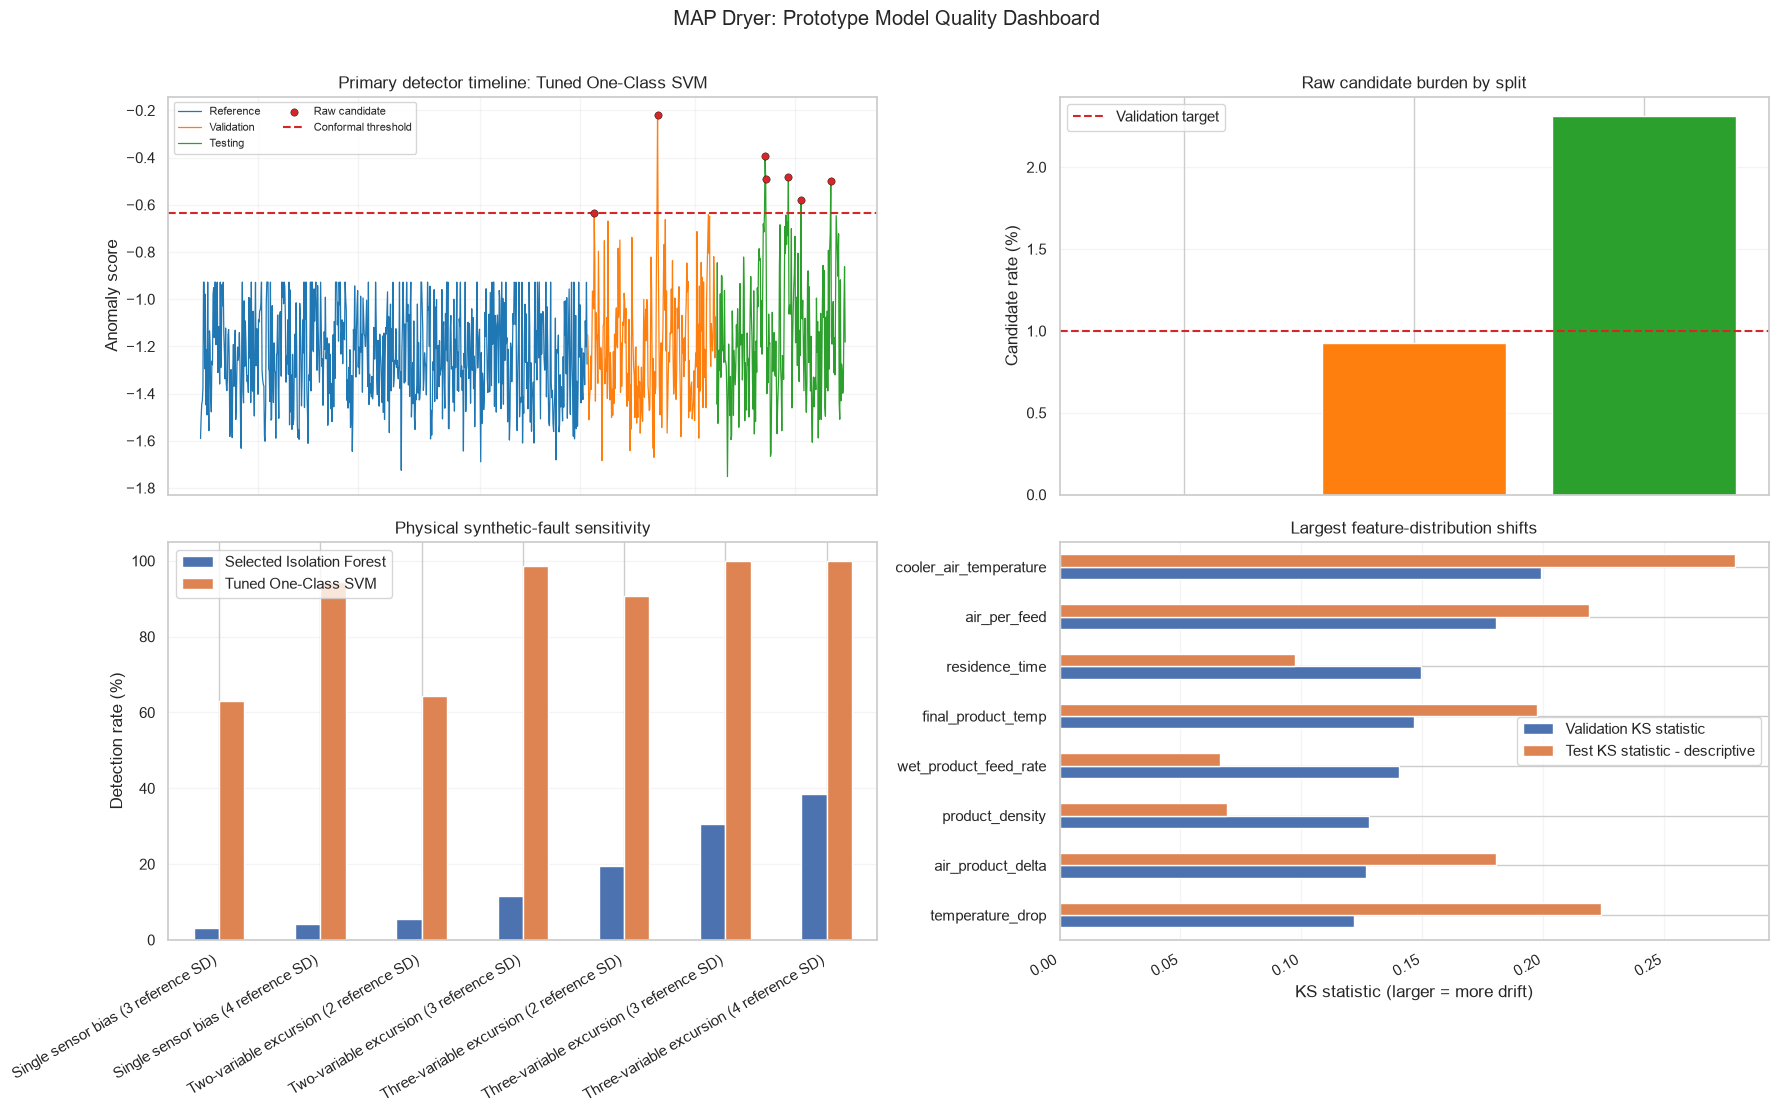

In [22]:
provisional_split_quality = (
    provisional_selected_score_results.groupby("Split", sort=False)
    .agg(
        Observations=("Anomaly score", "size"),
        Raw_candidates=("Raw anomaly flag", "sum"),
        Persistent_alarm_observations=("Persistent alarm", "sum"),
        Persistent_alarm_episodes=("Alarm episode", "nunique"),
    )
)
provisional_split_quality["Raw candidate rate (%)"] = (
    100
    * provisional_split_quality["Raw_candidates"]
    / provisional_split_quality["Observations"]
)
provisional_split_quality["Persistent alarm rate (%)"] = (
    100
    * provisional_split_quality["Persistent_alarm_observations"]
    / provisional_split_quality["Observations"]
)

final_quality_summary = pd.Series(
    {
        "Provisional primary detector": PROVISIONAL_SELECTED_DETECTOR,
        "Normal-reference rows": len(X_normal_reference),
        "Rows excluded by prototype limit filter": int(
            (~pcs7_reference_eligible_rows).sum()
        ),
        "Target validation raw candidate rate (%)": (
            100 * TARGET_VALIDATION_CANDIDATE_RATE
        ),
        "Observed validation raw candidate rate (%)": (
            provisional_split_quality.loc["Validation", "Raw candidate rate (%)"]
        ),
        "Test raw candidate rate (%) - descriptive": (
            provisional_split_quality.loc["Testing", "Raw candidate rate (%)"]
        ),
        "Mean synthetic scenario detection rate (%)": (
            100 * provisional_selected_synthetic_detection.mean()
        ),
        "Worst synthetic scenario detection rate (%)": (
            100 * provisional_selected_synthetic_detection.min()
        ),
    },
    name="Model quality status",
)
display(final_quality_summary.to_frame())
display(provisional_split_quality.round(4))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
timeline_axis = axes[0, 0]
for split_name, split_color in split_colors.items():
    split_rows = provisional_selected_score_results.loc[
        provisional_selected_score_results["Split"] == split_name
    ]
    timeline_axis.plot(
        split_rows["timestamp"],
        split_rows["Anomaly score"],
        color=split_color,
        linewidth=0.9,
        label=split_name,
    )
selected_candidates = provisional_selected_score_results.loc[
    provisional_selected_score_results["Raw anomaly flag"]
]
timeline_axis.scatter(
    selected_candidates["timestamp"],
    selected_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=28,
    zorder=4,
    label="Raw candidate",
)
timeline_axis.axhline(
    PROVISIONAL_SELECTED_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label="Conformal threshold",
)
timeline_axis.set_title(f"Primary detector timeline: {PROVISIONAL_SELECTED_DETECTOR}")
timeline_axis.set_ylabel("Anomaly score")
timeline_axis.legend(fontsize=8, ncol=2)
timeline_axis.grid(alpha=0.2)

candidate_rates = provisional_split_quality["Raw candidate rate (%)"]
axes[0, 1].bar(candidate_rates.index, candidate_rates.values, color=list(split_colors.values()))
axes[0, 1].axhline(
    100 * TARGET_VALIDATION_CANDIDATE_RATE,
    color="tab:red",
    linestyle="--",
    label="Validation target",
)
axes[0, 1].set_title("Raw candidate burden by split")
axes[0, 1].set_ylabel("Candidate rate (%)")
axes[0, 1].legend()
axes[0, 1].grid(axis="y", alpha=0.2)

synthetic_detector_comparison.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Physical synthetic-fault sensitivity")
axes[1, 0].set_ylabel("Detection rate (%)")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].grid(axis="y", alpha=0.2)

top_feature_drift = feature_drift_evaluation.head(8)[
    ["Validation KS statistic", "Test KS statistic - descriptive"]
].sort_values("Validation KS statistic")
top_feature_drift.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Largest feature-distribution shifts")
axes[1, 1].set_xlabel("KS statistic (larger = more drift)")
axes[1, 1].set_ylabel("")
axes[1, 1].grid(axis="x", alpha=0.2)

fig.suptitle(
    "MAP Dryer: Prototype Model Quality Dashboard",
    y=1.01,
)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "07_model_quality_dashboard.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 19. Configure diagnosis and build the reference profile

The detector remains unchanged. The diagnostic branch loads versioned feature, subsystem, rule, and threshold configuration, then builds robust medians, IQR/MAD values, quantiles, and temporal-change statistics from the same `X_normal_reference` used to fit the detector.

The resulting labels are **probable diagnoses** with **suspected causes** and recommended checks. Confidence measures how strongly the configured evidence supports a rule; it is not a probability.


In [23]:
DIAGNOSTIC_CONFIG_DIR = PROJECT_ROOT / "config"
DIAGNOSIS_FIGURE_OUTPUT_DIR = FIGURE_OUTPUT_DIR
DIAGNOSIS_FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_configuration = load_diagnostic_configuration(
    DIAGNOSTIC_CONFIG_DIR
)
validate_model_features(
    MODEL_FEATURES,
    diagnostic_configuration["feature_metadata"],
)
reference_profile = build_reference_profile(
    X_normal_reference,
    diagnostic_configuration["feature_metadata"],
)

feature_metadata_table = (
    pd.DataFrame.from_dict(
        diagnostic_configuration["feature_metadata"]["features"],
        orient="index",
    )
    .rename_axis("Feature")
    .loc[MODEL_FEATURES]
)
reference_profile_table = pd.DataFrame(reference_profile.statistics).T[
    ["median", "iqr", "mad", "q05", "q95", "delta_iqr"]
]

display(feature_metadata_table)
display(reference_profile_table.round(4))
print("Diagnostic configuration versions:", diagnostic_configuration["versions"])
print("Reference-profile rows (training only):", reference_profile.training_rows)


,unit,unit_status,kind,parents,subsystems,criticality,online_available,explanation_group
Feature,,,,,,,,
dryer_air_temperature,°C,prototype_unit,raw,[],[thermal_system],high,True,dryer_temperature
cooler_air_temperature,°C,prototype_unit,raw,[],[cooling_system],medium,True,cooler_temperature
air_flow_rate,m³/h,defined,raw,[],[drying_air_exhaust],high,True,air_supply
wet_product_feed_rate,m³/h,defined,raw,[],[feed_loading],high,True,feed_loading
product_inlet_temperature,°C,prototype_unit,raw,[],"[feed_loading, thermal_system]",medium,True,inlet_temperature
residence_time,min,prototype_unit,raw,[],[feed_loading],medium,True,residence_time
vacuum,mmH2O,defined,raw,[],[drying_air_exhaust],high,True,exhaust_pressure
steam_pressure,bar,defined,raw,[],[thermal_system],high,True,steam_supply
fan_speed,rpm,defined,raw,[],[drying_air_exhaust],high,True,air_supply


,median,iqr,mad,q05,q95,delta_iqr
dryer_air_temperature,139.5000,1.7000,0.8000,137.7000,141.3000,1.2000
cooler_air_temperature,23.4500,5.5000,2.6500,18.5000,28.3650,2.6000
air_flow_rate,23.8050,1.1625,0.5950,22.4635,25.1565,1.0250
wet_product_feed_rate,10.1850,0.6925,0.3450,9.5300,10.7900,0.1600
product_inlet_temperature,47.5000,2.0000,1.0000,45.1000,49.9000,1.7000
residence_time,20.5800,0.9025,0.4550,19.3900,21.5865,0.7100
vacuum,-0.9400,0.5000,0.2450,-1.5765,-0.4500,0.4000
steam_pressure,4.8000,0.2100,0.1100,4.5100,5.0765,0.2300
fan_speed,1261.0000,45.2500,23.0000,1211.0000,1313.0000,37.0000
product_density,1.0270,0.0060,0.0030,1.0180,1.0350,0.0100


Diagnostic configuration versions: {'feature_metadata': 'diag_features_v1.3', 'subsystems': 'diag_subsystems_v1.0', 'thresholds': 'diag_thresholds_v1.0', 'rules': 'diag_rules_v1.0'}
Reference-profile rows (training only): 648


## 20. Verify the diagnostic contracts

The reusable modules combine two localization signals: robust deviation from the reference profile and counterfactual One-Class SVM sensitivity. Feature evidence is normalized, grouped into subsystems without double counting, combined with recent temporal patterns, and evaluated through D01–D08.

Confidence measures rule-evidence agreement. Severity is calculated separately as a relative-priority score. The check below also verifies that the scoring adapter reproduces the notebook's OCSVM scores exactly, so diagnosis does not alter detector output.


In [24]:
ocsvm_scaled_timeline = pd.concat(
    [X_train_scaled, X_validation_scaled, X_test_scaled],
    axis=0,
).sort_index()
canonical_ocsvm_scores = canonical_anomaly_score(
    one_class_svm_model,
    ocsvm_scaled_timeline[MODEL_FEATURES],
)
stored_ocsvm_scores = (
    one_class_svm_score_results
    .sort_values("timestamp", kind="stable")["Anomaly score"]
    .to_numpy()
)
if not np.allclose(canonical_ocsvm_scores, stored_ocsvm_scores):
    raise AssertionError(
        "The diagnosis score adapter changed the existing OCSVM score contract."
    )

diagnostic_contract = pd.Series(
    {
        "Detector preserved": "Tuned One-Class SVM",
        "Score convention": "Higher score = more abnormal",
        "Detector score equality": True,
        "Feature localization": "40% robust deviation + 60% counterfactual sensitivity",
        "Configured diagnostic rules": len(
            diagnostic_configuration["rules"]["rules"]
        ),
        "Instrumentation guard": "Enabled",
        "Prediction target excluded from detector": True,
    },
    name="Diagnostic contract",
)
display(diagnostic_contract.to_frame())


,Diagnostic contract
Detector preserved,Tuned One-Class SVM
Score convention,Higher score = more abnormal
Detector score equality,True
Feature localization,40% robust deviation + 60% counterfactual sens...
Configured diagnostic rules,8
Instrumentation guard,Enabled
Prediction target excluded from detector,True


## 21. Diagnose persistent validation/test episodes

Create one diagnostic event per persistent alarm episode. The highest-scoring row represents the episode, and the engine uses only history at or before that timestamp. If no persistent episode exists, no diagnostic event is exported. Each event contains ranked feature evidence, subsystem scores, temporal patterns, probable diagnoses, suspected causes, recommended checks, severity, confidence, and configuration versions.


,Event ID,Timestamp,Severity,Primary subsystem,Probable diagnosis,Confidence,Top feature,Moisture target (context only)
0,MAPD-263B00C33675D26D,2026-07-10 21:00:00,MODERATE,thermal_system,Abnormal exhaust or pressure condition,0.72,product_inlet_temperature,0.085


ANOMALY DETECTED | Severity: MODERATE | Primary subsystem: thermal_system | Probable diagnosis: Abnormal exhaust or pressure condition | Confidence: 72% (HIGH). Observed evidence: product_inlet_temperature HIGH (25%), air_product_delta LOW (18%), cooler_air_temperature HIGH (15%). Suspected causes requiring verification: Exhaust fan problem, Duct restriction, Damper-position problem. Recommended checks: Verify the vacuum measurement; Inspect the exhaust fan and duct restrictions; Check dampers and leak paths. Model-based operational severity; not a safety classification.



,feature,direction,current_value,reference_median,robust_z,robust_deviation,counterfactual_contribution,attribution,unit,kind,parents,subsystems,criticality,explanation_group
0,product_inlet_temperature,HIGH,50.50,47.50,1.5000,1.5000,0.3722,0.2522,°C,raw,[],"[feed_loading, thermal_system]",medium,inlet_temperature
1,air_product_delta,LOW,86.80,91.90,-1.9615,1.9615,0.2388,0.1811,Δ°C,engineered,"[dryer_air_temperature, product_inlet_temperat...","[thermal_system, feed_loading]",medium,inlet_temperature
2,cooler_air_temperature,HIGH,32.80,23.45,1.7000,1.7000,0.1891,0.1462,°C,raw,[],[cooling_system],medium,cooler_temperature
3,temperature_drop,HIGH,101.30,96.20,2.1250,2.1250,0.0901,0.0950,Δ°C,engineered,"[dryer_air_temperature, final_product_temp]","[thermal_system, cooling_system]",medium,dryer_temperature
4,residence_time,NORMAL,19.57,20.58,-1.1191,1.1191,0.0687,0.0628,min,raw,[],[feed_loading],medium,residence_time


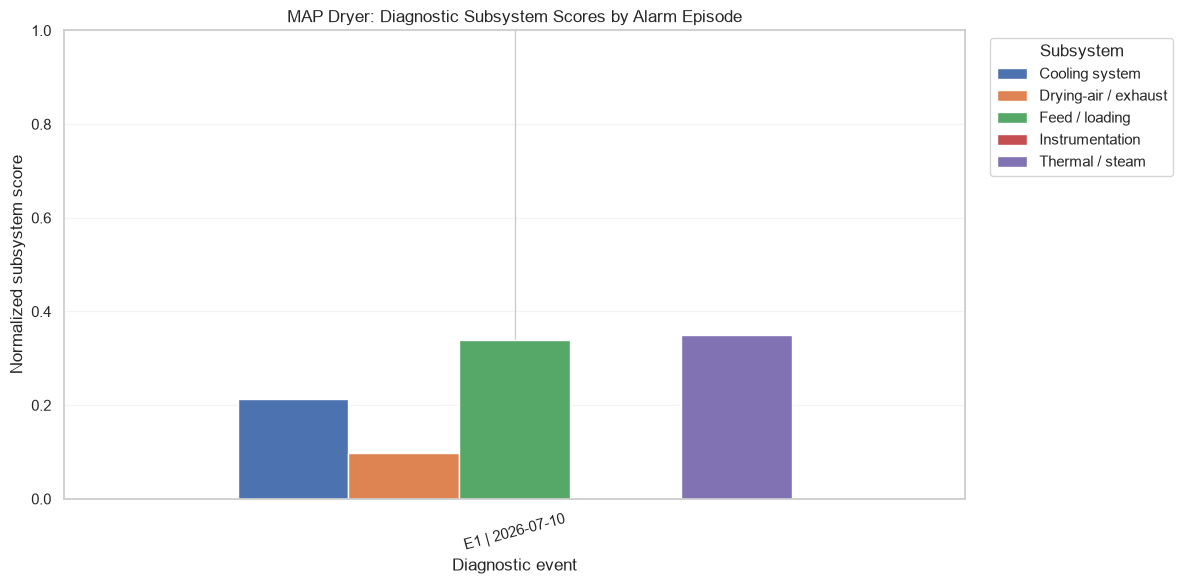

In [25]:
diagnostic_score_results = one_class_svm_score_results.copy()
episode_rows = diagnostic_score_results.loc[
    diagnostic_score_results["Persistent alarm"]
    & diagnostic_score_results["Split"].isin(["Validation", "Testing"])
    & diagnostic_score_results["Alarm episode"].notna()
].copy()

if episode_rows.empty:
    representative_rows = episode_rows.copy()
    print("No persistent validation/test episode was available for event export.")
else:
    representative_indices = episode_rows.groupby(
        ["Split", "Alarm episode"], sort=False
    )["Anomaly score"].idxmax()
    representative_rows = diagnostic_score_results.loc[
        representative_indices
    ].sort_values("timestamp", kind="stable")

history_window = int(
    diagnostic_configuration["thresholds"]["temporal"]["history_window"]
)
diagnostic_events = []
for _, representative in representative_rows.iterrows():
    event_timestamp = pd.Timestamp(representative["timestamp"])
    history = ordered_anomaly_data.loc[
        ordered_anomaly_data["timestamp"] <= event_timestamp,
        MODEL_FEATURES,
    ].tail(history_window)
    current = history.iloc[-1]
    pcs7_row = pcs7_limit_results.loc[
        pcs7_limit_results["timestamp"] == event_timestamp
    ].iloc[0]
    lab_moisture = dryerMAP_model.loc[
        dryerMAP_model["timestamp"] == event_timestamp,
        "final_moisture_h₂o",
    ].iloc[0]
    diagnostic_events.append(
        diagnose_anomaly(
            timestamp=event_timestamp,
            anomaly=True,
            anomaly_score=representative["Anomaly score"],
            threshold=ONE_CLASS_SVM_THRESHOLD,
            x_current=current,
            history_df=history,
            model=one_class_svm_model,
            scaler=anomaly_scaler,
            reference_profile=reference_profile,
            feature_metadata=diagnostic_configuration["feature_metadata"],
            subsystem_config=diagnostic_configuration["subsystems"],
            rule_config=diagnostic_configuration["rules"],
            threshold_config=diagnostic_configuration["thresholds"],
            config_versions=diagnostic_configuration["versions"],
            approved_limit_crossing=(
                USE_PCS7_LIMITS_FOR_REFERENCE_FILTER and bool(pcs7_row["PCS7 rule breach"])
            ),
            lab_moisture_after_event=float(lab_moisture),
            notes="Prototype diagnostic event.",
        )
    )

diagnostic_event_summary = pd.DataFrame(
    [
        {
            "Event ID": event.event_id,
            "Timestamp": event.timestamp,
            "Severity": event.severity,
            "Primary subsystem": event.primary_subsystem,
            "Probable diagnosis": (
                event.diagnoses[0].diagnosis
                if event.diagnoses
                else "Insufficient diagnostic evidence"
            ),
            "Confidence": (
                event.diagnoses[0].confidence if event.diagnoses else np.nan
            ),
            "Top feature": (
                event.top_features[0].feature if event.top_features else None
            ),
            "Moisture target (context only)": event.lab_moisture_after_event,
        }
        for event in diagnostic_events
    ]
)
display(diagnostic_event_summary.round({"Confidence": 3}))
for event in diagnostic_events:
    print(format_operator_report(event))
    print()

if diagnostic_events:
    first_event_evidence = pd.DataFrame(
        [item.as_dict() for item in diagnostic_events[0].top_features]
    )
    display(first_event_evidence.round(4))

    subsystem_score_table = pd.DataFrame(
        [event.subsystem_scores for event in diagnostic_events],
        index=[
            f"E{event_index + 1} | {pd.Timestamp(event.timestamp):%Y-%m-%d}"
            for event_index, event in enumerate(diagnostic_events)
        ],
    ).fillna(0.0)
    subsystem_display_names = {
        name: details["display_name"]
        for name, details in diagnostic_configuration["subsystems"][
            "subsystems"
        ].items()
    }
    subsystem_score_table = subsystem_score_table.rename(
        columns=subsystem_display_names
    )
    axis = subsystem_score_table.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8,
    )
    axis.set_title("MAP Dryer: Diagnostic Subsystem Scores by Alarm Episode")
    axis.set_xlabel("Diagnostic event")
    axis.set_ylabel("Normalized subsystem score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.2)
    axis.legend(title="Subsystem", bbox_to_anchor=(1.02, 1), loc="upper left")
    axis.figure.tight_layout()
    axis.figure.savefig(
        DIAGNOSIS_FIGURE_OUTPUT_DIR / "08_episode_subsystem_scores.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 22. Run physical scenarios and the deterministic unit suite

The eight scenarios modify raw process measurements first, recompute all engineered features, apply the unchanged OCSVM detector, and then invoke diagnosis.

The green `PASS` matrix contains two independent checks for each scenario:

1. **Detector raised anomaly:** the synthetic observation crossed the raw OCSVM threshold.
2. **Expected rule returned:** the intended D01–D08 rule appeared in the ranked diagnosis list.

This matrix deliberately bypasses the two-of-three persistence gate. It is a deterministic detector/rule acceptance check, not one combined accuracy score. D06 and D07 must rank first to protect against instrumentation errors; the other expected rules only need to be returned.


,Injected behavior,Anomaly score,Detected,Expected rule,Top returned rule,Expected rule returned
Scenario,,,,,,
S01,Airflow loss,-0.0926,True,D01,D01,True
S02,Steam loss,-0.0340,True,D02,D02,True
S03,Feed overload,-0.0032,True,D03,D03,True
S04,Cooling degradation,-0.0036,True,D04,D04,True
S05,Exhaust restriction,-0.0246,True,D05,D05,True
S06,Temperature sensor jump,-0.0001,True,D06,D06,True
S07,Stuck fan-speed signal,-0.2732,True,D07,D07,True
S08,Oscillatory control,-0.0465,True,D08,D05,True


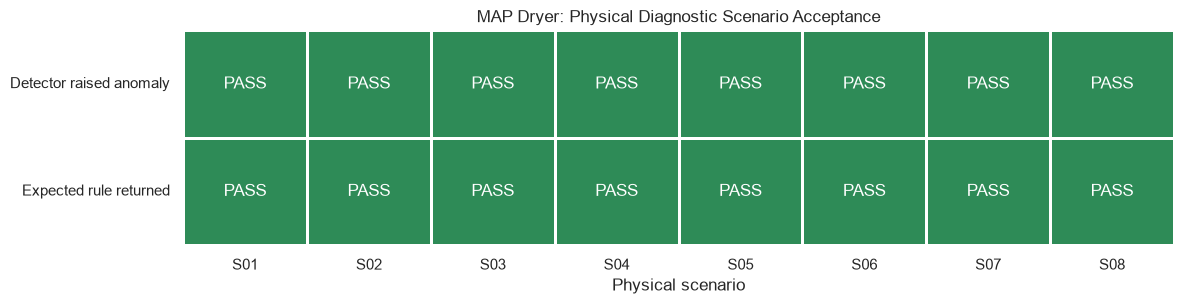


----------------------------------------------------------------------
Ran 28 tests in 2.116s

OK



In [26]:
physical_scenarios = build_physical_scenarios(reference_profile)
scenario_rows = []
for scenario_id, scenario in physical_scenarios.items():
    scenario_score = float(
        canonical_anomaly_score(
            one_class_svm_model,
            anomaly_scaler.transform(
                scenario.current.to_frame().T[MODEL_FEATURES]
            ),
        )[0]
    )
    detected = scenario_score >= ONE_CLASS_SVM_THRESHOLD
    scenario_event = diagnose_anomaly(
        timestamp=pd.Timestamp("2030-01-01")
        + pd.Timedelta(hours=2 * int(scenario_id[1:])),
        anomaly=detected,
        anomaly_score=scenario_score,
        threshold=ONE_CLASS_SVM_THRESHOLD,
        x_current=scenario.current,
        history_df=scenario.history,
        model=one_class_svm_model,
        scaler=anomaly_scaler,
        reference_profile=reference_profile,
        feature_metadata=diagnostic_configuration["feature_metadata"],
        subsystem_config=diagnostic_configuration["subsystems"],
        rule_config=diagnostic_configuration["rules"],
        threshold_config=diagnostic_configuration["thresholds"],
        config_versions=diagnostic_configuration["versions"],
    )
    returned_rules = [result.rule_id for result in scenario_event.diagnoses]
    scenario_rows.append(
        {
            "Scenario": scenario_id,
            "Injected behavior": scenario.name,
            "Anomaly score": scenario_score,
            "Detected": detected,
            "Expected rule": scenario.expected_rule_id,
            "Top returned rule": returned_rules[0] if returned_rules else None,
            "Expected rule returned": scenario.expected_rule_id in returned_rules,
        }
    )

scenario_acceptance = pd.DataFrame(scenario_rows).set_index("Scenario")
if not scenario_acceptance["Detected"].all():
    raise AssertionError("At least one physical scenario was not detected by OCSVM.")
if not scenario_acceptance["Expected rule returned"].all():
    raise AssertionError("At least one physical scenario missed its expected rule.")
if scenario_acceptance.loc["S06", "Top returned rule"] != "D06":
    raise AssertionError("Instrumentation jump did not outrank process-fault rules.")
if scenario_acceptance.loc["S07", "Top returned rule"] != "D07":
    raise AssertionError("Stuck-sensor diagnosis did not rank first.")
display(scenario_acceptance.round({"Anomaly score": 4}))

acceptance_plot = scenario_acceptance[
    ["Detected", "Expected rule returned"]
].astype(int).T
acceptance_plot.index = ["Detector raised anomaly", "Expected rule returned"]
figure, axis = plt.subplots(figsize=(12, 3.2))
sns.heatmap(
    acceptance_plot,
    annot=acceptance_plot.replace({1: "PASS", 0: "FAIL"}),
    fmt="",
    cmap=sns.color_palette(["#c0392b", "#2e8b57"], as_cmap=True),
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=axis,
)
axis.set_title("MAP Dryer: Physical Diagnostic Scenario Acceptance")
axis.set_xlabel("Physical scenario")
axis.set_ylabel("")
axis.tick_params(axis="x", rotation=0)
axis.tick_params(axis="y", rotation=0)
figure.tight_layout()
figure.savefig(
    DIAGNOSIS_FIGURE_OUTPUT_DIR / "09_physical_scenario_acceptance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

test_environment = os.environ.copy()
test_environment["PYTHONPATH"] = str(SRC_DIR)
unit_test_run = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-q"],
    cwd=PROJECT_ROOT,
    env=test_environment,
    capture_output=True,
    text=True,
    check=False,
)
print(unit_test_run.stdout)
print(unit_test_run.stderr)
if unit_test_run.returncode != 0:
    raise AssertionError("The deterministic diagnostic unit suite failed.")


## 23. Export diagnostic events and versioned metadata

The final-moisture target is attached to an event only as additional context; it is never used for anomaly scoring, localization, diagnostic rules, confidence, or severity. The final cell exports the diagnostic-event JSON and a metadata bundle containing the detector score convention, threshold, reference profile, exact feature order, configuration versions, and configuration hashes.


In [27]:
DIAGNOSTIC_MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "diagnosis"
DIAGNOSTIC_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_events_path = (
    DIAGNOSTIC_MODEL_OUTPUT_DIR
    / "validation_test_diagnostic_events.diag_v1.0.json"
)
diagnostic_events_path.write_text(
    json.dumps(
        [event.as_dict() for event in diagnostic_events],
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

diagnostic_bundle_path = save_diagnostic_bundle_metadata(
    DIAGNOSTIC_MODEL_OUTPUT_DIR / "diagnostic_bundle_metadata.diag_v1.0.json",
    detector_name="Tuned One-Class SVM",
    detector_parameters=best_one_class_svm_parameters,
    anomaly_threshold=ONE_CLASS_SVM_THRESHOLD,
    model_features=MODEL_FEATURES,
    reference_profile=reference_profile,
    config_versions=diagnostic_configuration["versions"],
    config_hashes=diagnostic_configuration["hashes"],
    diagnostic_version=diagnostic_configuration["thresholds"][
        "diagnostic_version"
    ],
)
prototype_outputs = pd.Series(
    {
        "Diagnostic events JSON": diagnostic_events_path,
        "Diagnostic bundle metadata": diagnostic_bundle_path,
        "Configuration versions": diagnostic_configuration["versions"],
        "Reference rows": reference_profile.training_rows,
        "Prediction target excluded from detector": True,
    },
    name="Prototype output",
)
display(prototype_outputs.to_frame())


,Prototype output
Diagnostic events JSON,C:\Users\pc\Documents\GitHub\PROJECTS\MAP-Drye...
Diagnostic bundle metadata,C:\Users\pc\Documents\GitHub\PROJECTS\MAP-Drye...
Configuration versions,"{'feature_metadata': 'diag_features_v1.3', 'su..."
Reference rows,648
Prediction target excluded from detector,True


## Prototype summary

Notebook 04 now provides a complete prototype chain: detector comparison, detector-specific thresholds, raw candidates, two-of-three persistence, feature localization, subsystem scoring, temporal analysis, configurable D01–D08 rules, separate confidence and severity, deterministic scenario checks, JSON events, and versioned metadata.

The key reading order is: **input feature → anomaly score → raw candidate → persistent alarm → diagnostic event**.


## Next step

Use the exported event JSON in a future operator interface, then adjust prototype thresholds or diagnostic-rule weights only when the scenario matrix and unit tests continue to pass.
